# Data

In [1]:
import os
import numpy as np 
import pandas as pd 
pd.pandas.set_option('display.max_columns',None)
pd.pandas.set_option('display.max_rows',None)

In [2]:
train_path = "/kaggle/input/competitions/playground-series-s6e3/train.csv"
test_path = "/kaggle/input/competitions/playground-series-s6e3/test.csv"
submission_path = "/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
submission = pd.read_csv(submission_path)

NN_train = train.copy()
NN_test = test.copy()

train.head(2)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No


In [3]:
print("The train data shape is {}".format(train.shape))
print("The test data shape is {}".format(test.shape))

The train data shape is (594194, 21)
The test data shape is (254655, 20)


In [4]:
remove_features=['id']
train=train.drop(columns=remove_features,axis=1)
test=test.drop(columns=remove_features,axis=1)

# Target Distribution

In [5]:
train["Churn"].value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

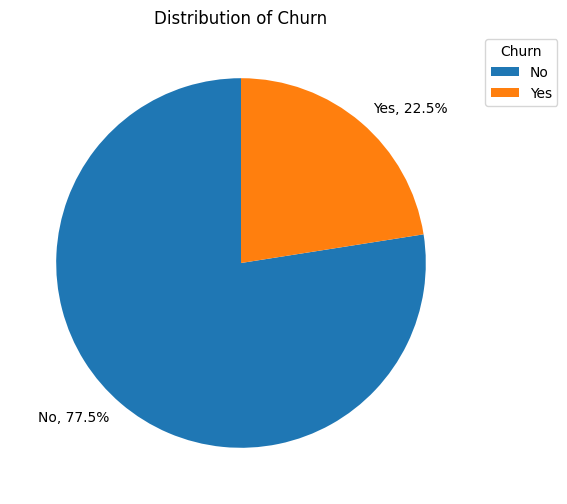

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

# Counting the observations for each category
LABEL="Churn"
status_counts = train[LABEL].value_counts()
labels = status_counts.index
sizes = status_counts.values

# Calculating the percentage of each category
percentages = 100.*sizes/sizes.sum()

# Creating the pie chart with percentages in the labels
plt.figure(figsize=(10, 6))
plt.pie(sizes, labels=[f"{l}, {s:.1f}%" for l, s in zip(labels, percentages)], startangle=90)
plt.gca().set_aspect("equal")
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1), labels=labels, title=LABEL)
plt.title(f"Distribution of {LABEL}")
plt.show()

In [7]:
train['Churn'] = train['Churn'].map({'No': 0, 'Yes': 1})

# Unique & Missing Values

In [8]:
from prettytable import PrettyTable

target="Churn"
train_copy = train.copy()
test_copy = test.copy()

# create a table
table = PrettyTable()

# columns names
table.field_names = ['Feature', 'Data Type', 'Train Missing %', 'Test Missing %']

for column in train_copy.columns:
    data_type = str(train_copy[column].dtype)
    non_null_count_train= np.round(100-train_copy[column].count()/train_copy.shape[0]*100,1)
    if column!=target:
        non_null_count_test = np.round(100-test_copy[column].count()/test_copy.shape[0]*100,1)
    else:
        non_null_count_test="NA"
    #non_null_count_orig= np.round(100-original_copy[column].count()/original_copy.shape[0]*100,1)
    table.add_row([column, data_type, non_null_count_train,non_null_count_test])
print(table)

+------------------+-----------+-----------------+----------------+
|     Feature      | Data Type | Train Missing % | Test Missing % |
+------------------+-----------+-----------------+----------------+
|      gender      |   object  |       0.0       |      0.0       |
|  SeniorCitizen   |   int64   |       0.0       |      0.0       |
|     Partner      |   object  |       0.0       |      0.0       |
|    Dependents    |   object  |       0.0       |      0.0       |
|      tenure      |   int64   |       0.0       |      0.0       |
|   PhoneService   |   object  |       0.0       |      0.0       |
|  MultipleLines   |   object  |       0.0       |      0.0       |
| InternetService  |   object  |       0.0       |      0.0       |
|  OnlineSecurity  |   object  |       0.0       |      0.0       |
|   OnlineBackup   |   object  |       0.0       |      0.0       |
| DeviceProtection |   object  |       0.0       |      0.0       |
|   TechSupport    |   object  |       0.0      

In [9]:
def compare_features(train_df, test_df, features):
    if isinstance(features, str):
        features = [features]

    summary = []
    for col in features:
        res = {"Feature": col}
        
        in_train = col in train_df.columns
        in_test = col in test_df.columns
        
        if in_train and in_test:
            train_set = set(train_df[col].unique())
            test_set = set(test_df[col].unique())
            
            res.update({
                "Type": str(train_df[col].dtype),
                "Train Unique": len(train_set),
                "Test Unique": len(test_set),
                "New in Test": list(test_set - train_set), 
                "Missing in Test": list(train_set - test_set),
                "Overlap %": f"{(len(train_set & test_set) / len(train_set | test_set)):.2%}"
            })
        else:
            res.update({"Status": "Missing in one of the dataframes"})
            
        summary.append(res)
        
    return pd.DataFrame(summary)

train_features = train.columns.tolist()
comparison_df = compare_features(train, test, train_features)
display(comparison_df)

,Feature,Type,Train Unique,Test Unique,New in Test,Missing in Test,Overlap %,Status
0,gender,object,2.0,2.0,[],[],100.00%,NaN
1,SeniorCitizen,int64,2.0,2.0,[],[],100.00%,NaN
2,Partner,object,2.0,2.0,[],[],100.00%,NaN
3,Dependents,object,2.0,2.0,[],[],100.00%,NaN
4,tenure,int64,72.0,72.0,[],[],100.00%,NaN
5,PhoneService,object,2.0,2.0,[],[],100.00%,NaN
6,MultipleLines,object,3.0,3.0,[],[],100.00%,NaN
7,InternetService,object,3.0,3.0,[],[],100.00%,NaN
8,OnlineSecurity,object,3.0,3.0,[],[],100.00%,NaN
9,OnlineBackup,object,3.0,3.0,[],[],100.00%,NaN


# Features Distribution

In [10]:
nums_cols = ["tenure","MonthlyCharges","TotalCharges"]

cate_cols = [
    col for col in train.columns
    if (train[col].dtype == "object" or train[col].nunique()<10)
    and col != "Churn"
]

cate_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

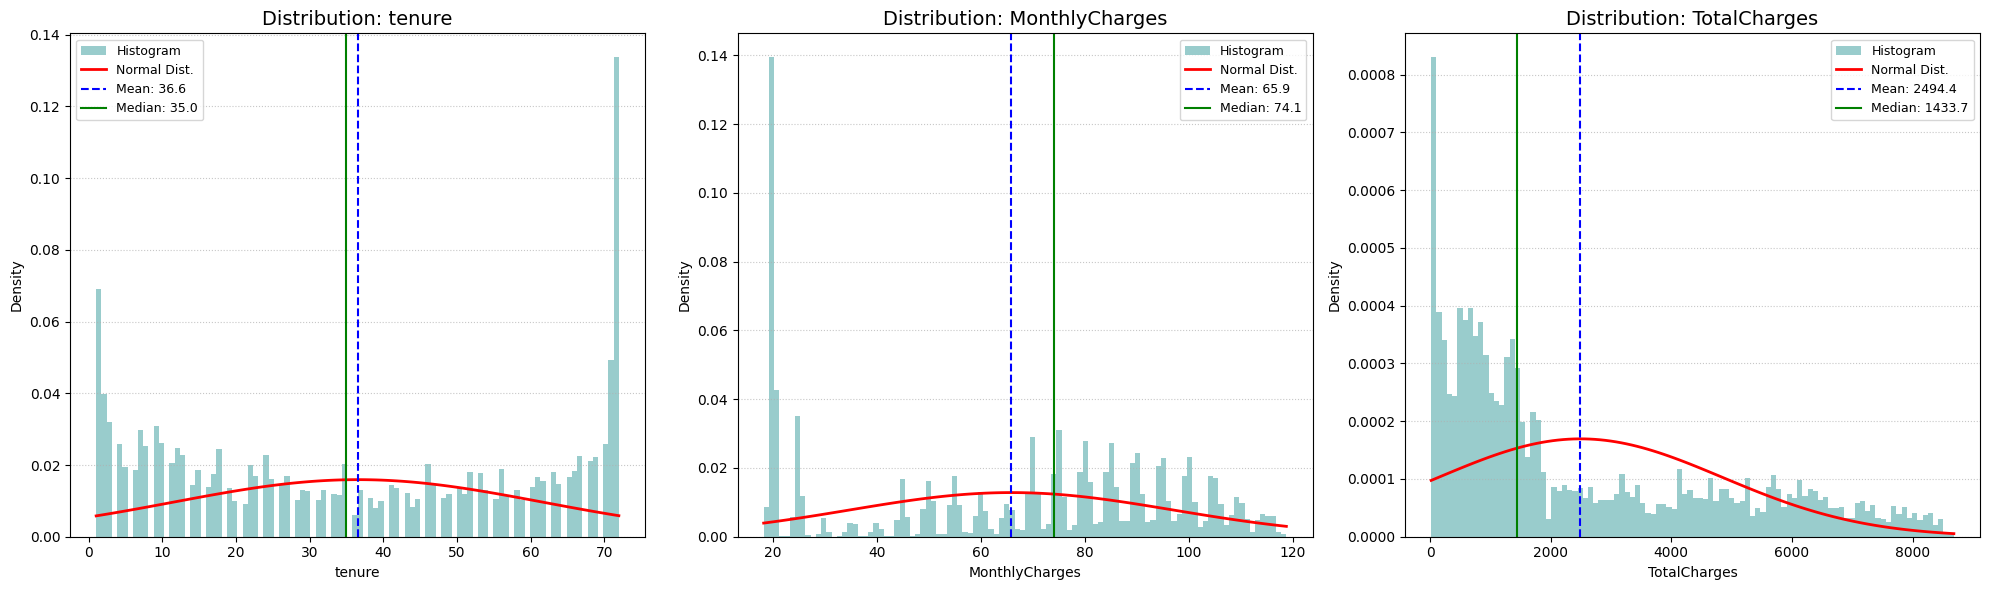

In [11]:
from scipy.stats import norm

def plot_nums_features(df, features):

    target_features = features[:3]
    num_cols = len(target_features)
    
    fig, axes = plt.subplots(nrows=1, ncols=num_cols, figsize=(20, 6))
    
    if num_cols == 1:
        axes = [axes]
        
    for i, col in enumerate(target_features):
        ax = axes[i]
        data = df[col].dropna()
        
        mean_val = np.mean(data)
        median_val = np.median(data)
        std_val = np.std(data)
        
        ax.hist(data, bins=100, density=True, alpha=0.4, color='teal', label='Histogram')
        
        x_values = np.linspace(data.min(), data.max(), 100)
        ax.plot(x_values, norm.pdf(x_values, mean_val, std_val), 
                color='red', lw=2, label='Normal Dist.')
        
        ax.axvline(mean_val, color='blue', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
        ax.axvline(median_val, color='green', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.1f}')
        
        ax.set_title(f'Distribution: {col}', fontsize=14)
        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)
        ax.grid(axis='y', linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_nums_features(train, nums_cols)

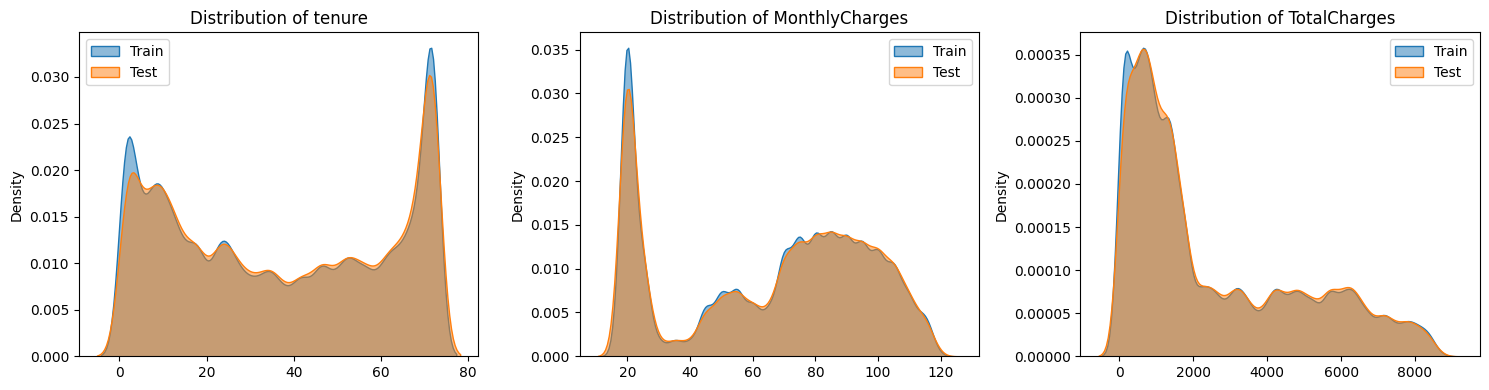

In [12]:
import math
import seaborn as sns

def plot_continuous_distribution(train, test, features, cols=3):
    
    rows = math.ceil(len(features) / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = axes.flatten() 

    for i, col in enumerate(features):
        sns.kdeplot(data=train, x=col, fill=True, ax=axes[i], label='Train', color='#1f77b4', alpha=0.5)
        sns.kdeplot(data=test, x=col, fill=True, ax=axes[i], label='Test', color='#ff7f0e', alpha=0.5)
        
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].legend()

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

plot_continuous_distribution(train, test, features=nums_cols)

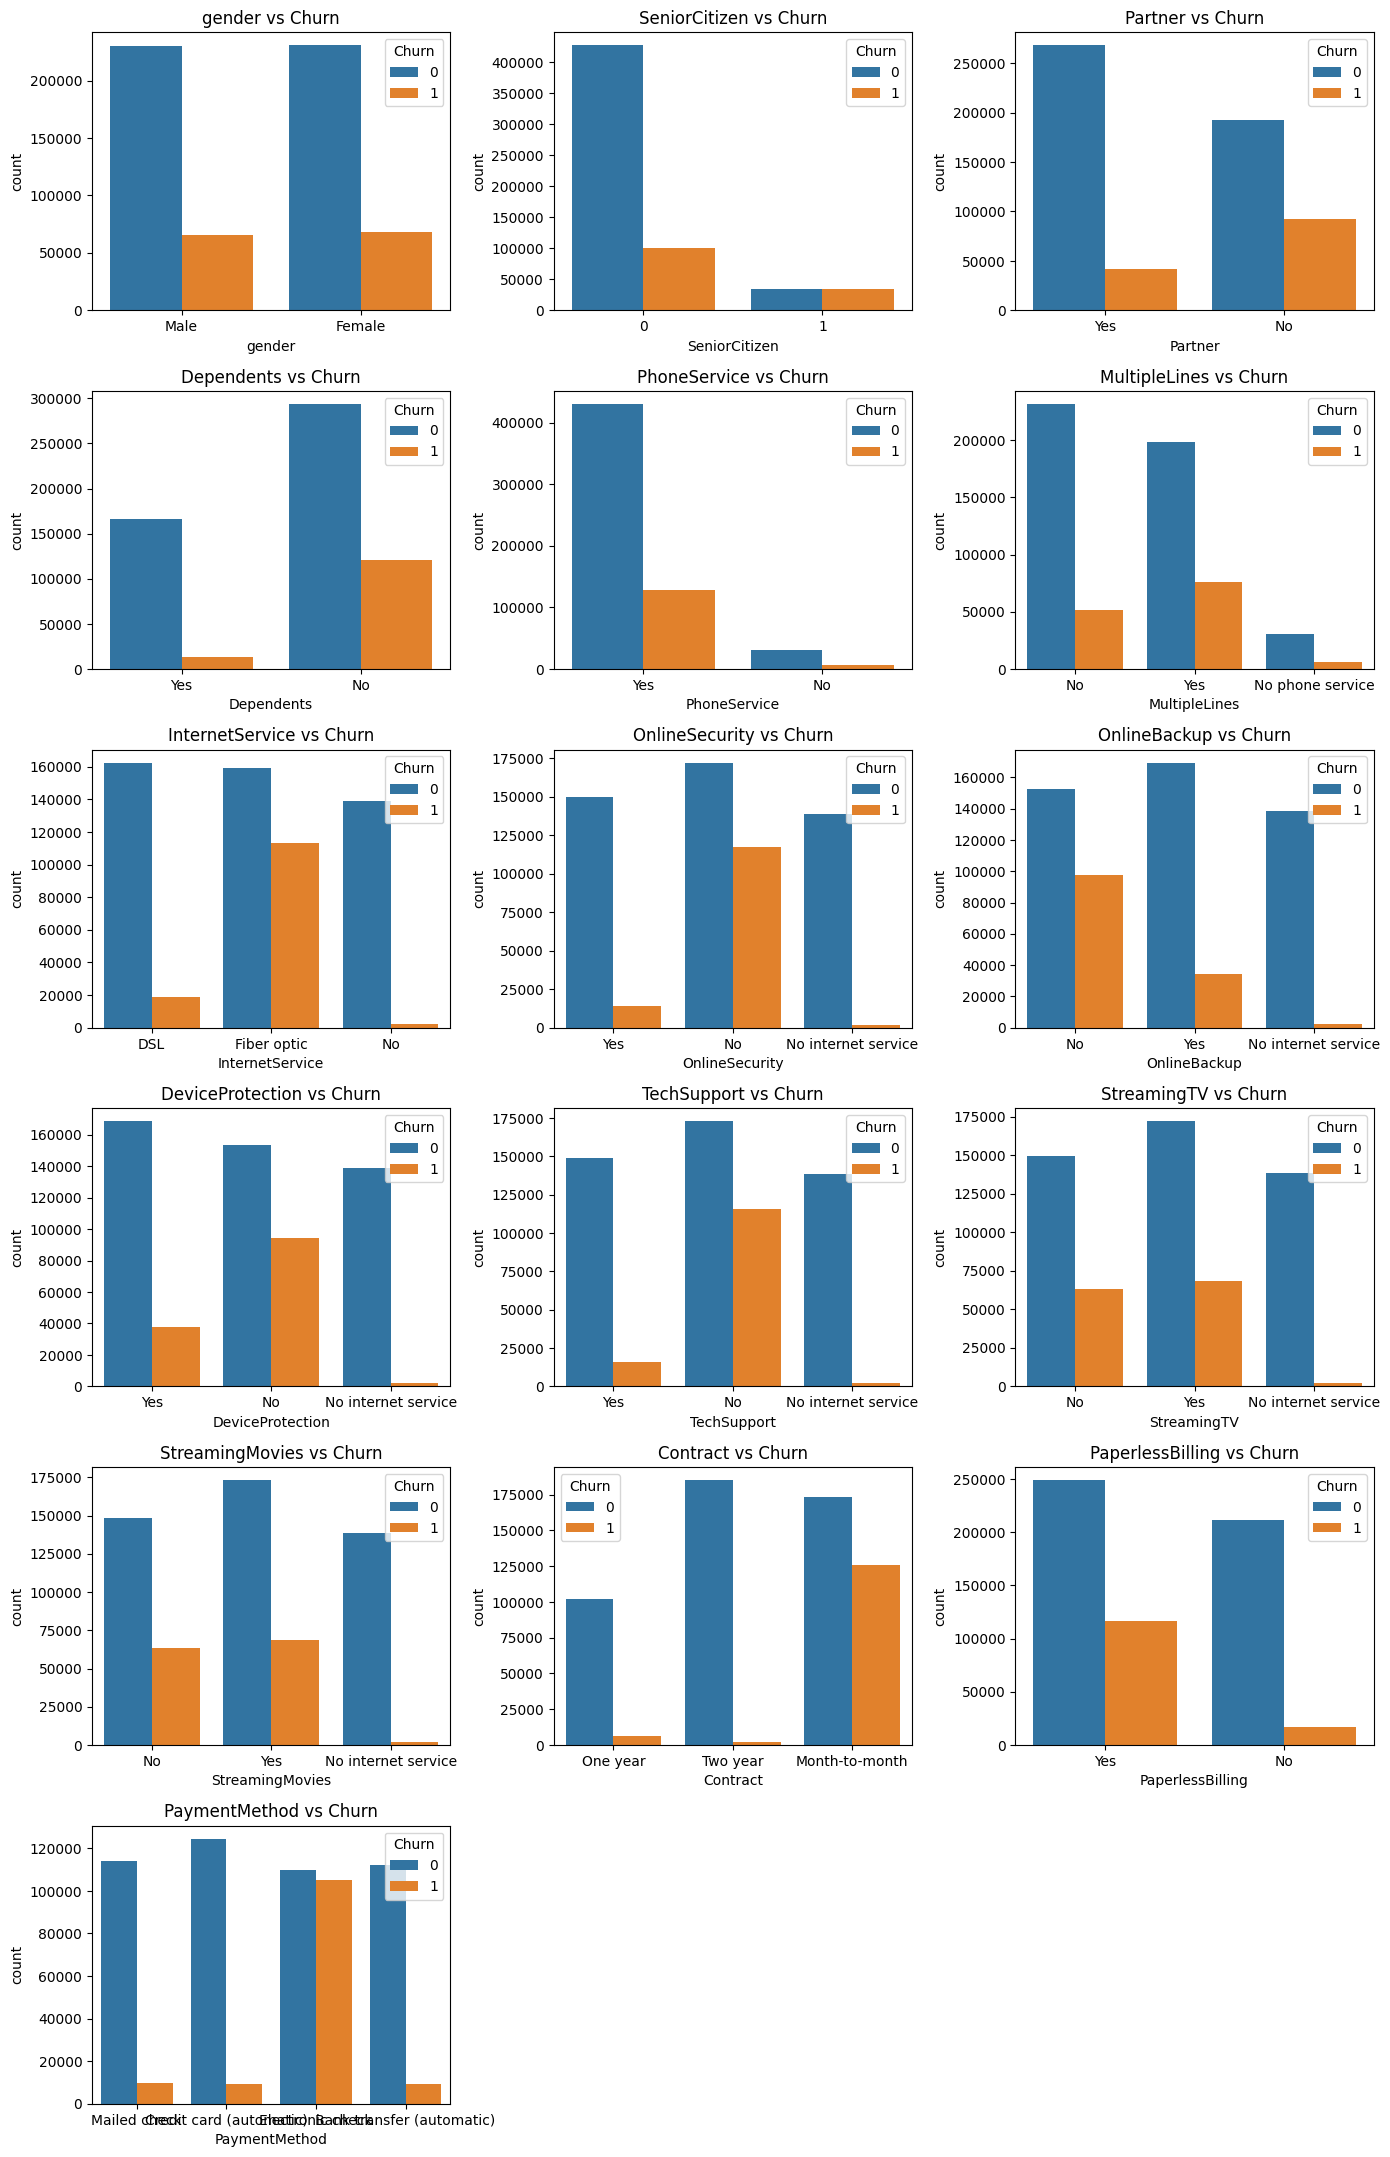

In [13]:
import warnings
warnings.filterwarnings("ignore")

LABEL = "Churn"

plt.figure(figsize=(14, len(cate_cols) * 2))
for i, col in enumerate(cate_cols):
    plt.subplot(len(cate_cols) // 2 + 1, 3, i + 1)
    sns.countplot(x=col, hue=LABEL, data=train)
    plt.title(f"{col} vs {LABEL}")
    plt.tight_layout()

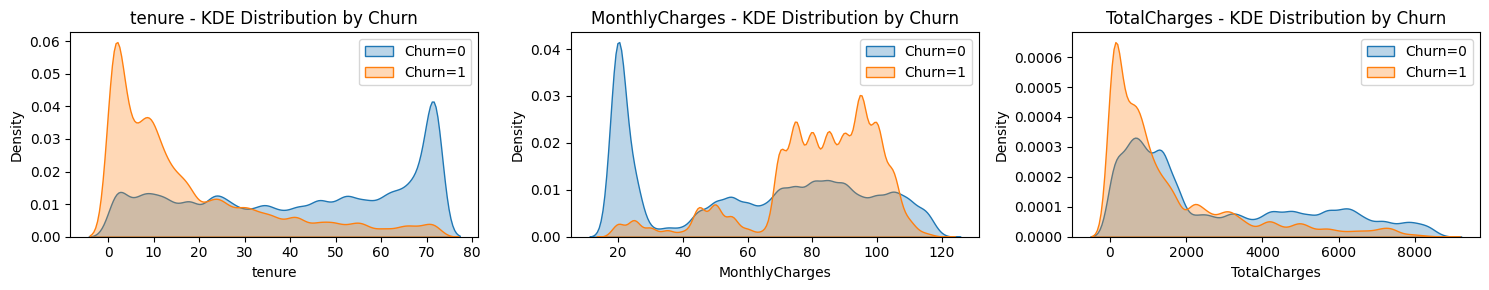

In [14]:
def plot_kde_by_label(df, nums_cols, label_col, n_cols=3, figsize_per_plot=(5,3), alpha=0.3):
    n_rows = int(len(nums_cols) / n_cols) + (len(nums_cols) % n_cols != 0)
    plt.figure(figsize=(figsize_per_plot[0]*n_cols, figsize_per_plot[1]*n_rows))

    for i, col in enumerate(nums_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        for label in df[label_col].unique():
            subset = df[df[label_col] == label]
            sns.kdeplot(subset[col], label=f"{label_col}={label}", fill=True, alpha=alpha)
        
        plt.title(f"{col} - KDE Distribution by {label_col}")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
plot_kde_by_label(train, nums_cols, LABEL)

# Derive_binary_formula

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def derive_binary_formula(df, target_col, categorical_cols, continuous_cols):

    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    features = [c for c in df_encoded.columns if c != target_col]
    X = df_encoded[features]
    y = df_encoded[target_col]
    
    scaler = StandardScaler()
    X_scaled = X.copy()
    X_scaled[features] = scaler.fit_transform(X[features])
    
    model = LogisticRegression(penalty=None, solver='lbfgs')
    model.fit(X_scaled, y)
    
    weights = model.coef_[0]
    intercept = model.intercept_[0]
    
    abs_weights = np.abs(weights)
    total_impact = np.sum(abs_weights)
    importance_ratios = (abs_weights / total_impact) * 100
    odds_ratios = np.exp(weights)
    
    results = pd.DataFrame({
        'Feature': features,
        'Coefficient': weights,
        'Odds_Ratio': odds_ratios,
        'Importance_Ratio_Pct': importance_ratios
    }).sort_values(by='Importance_Ratio_Pct', ascending=False)
    
    intercept_row = pd.DataFrame({
        'Feature': ['(Intercept)'],
        'Coefficient': [intercept],
        'Odds_Ratio': [np.exp(intercept)],
        'Importance_Ratio_Pct': [np.nan] 
    })
    results = pd.concat([intercept_row, results], ignore_index=True)
    
    formula_str = f"Logit(P) = {intercept:.4f}"
    for f, w in zip(features, weights):
        sign = "+" if w >= 0 else "-"
        formula_str += f" {sign} ({abs(w):.4f} * {f})"
    
    return results, formula_str


report, formula = derive_binary_formula(
    df=train, 
    target_col='Churn', 
    categorical_cols=cate_cols, 
    continuous_cols=nums_cols
)

print("--- Feautures Important Analysis ---")
print(report.to_string(index=False, formatters={
    'Coefficient': '{:,.4f}'.format,
    'Odds_Ratio': '{:,.4f}'.format,
    'Importance_Ratio_Pct': '{:,.2f}%'.format
}))
print("\n--- Inverse generation formula (Logit space) ---")
print(formula)

--- Feautures Important Analysis ---
                              Feature Coefficient Odds_Ratio Importance_Ratio_Pct
                          (Intercept)     -2.6651     0.0696                  NaN
                  tenure_resid_zscore     -5.2549     0.0052               21.39%
                         tenure_resid     -5.2549     0.0052               21.39%
                               tenure      4.7399   114.4284               19.29%
                        tenure_scaled      4.7399   114.4284               19.29%
                    Contract_Two year     -0.8429     0.4304                3.43%
          InternetService_Fiber optic      0.4616     1.5866                1.88%
                    Contract_One year     -0.3610     0.6969                1.47%
       PaymentMethod_Electronic check      0.3228     1.3810                1.31%
                     tenure_resid_abs      0.2308     1.2596                0.94%
                 PaperlessBilling_Yes      0.2058     1.2285 

# Numerical Features - Rolling + Decision Stump

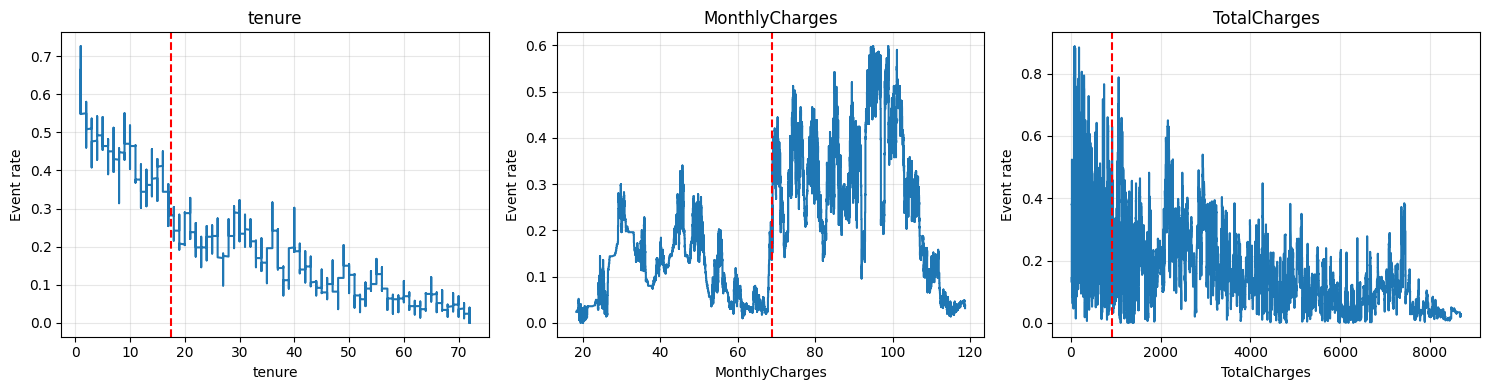

,feature,threshold,left_n,left_event_rate,right_n,right_event_rate,diff,abs_diff,min_leaf_n,edge_split,signal
0,tenure,17.500000,189289,0.468353,404905,0.111540,-0.356813,0.356813,189289,False,strong
1,MonthlyCharges,68.974998,258103,0.075586,336091,0.340110,0.264524,0.264524,258103,False,strong
2,TotalCharges,920.225006,208521,0.346843,385673,0.159443,-0.187399,0.187399,208521,False,strong


In [19]:
from sklearn.tree import DecisionTreeClassifier
import math

def plot_rolling_with_stump_multi(
    df,
    features,
    target,
    window=500,
    min_periods=100,
    min_samples_leaf=200,
    n_cols=3
):
    """
    Rolling target mean + decision stump visualization (multi-feature)

    Returns
    -------
    results : list of dict
        Raw per-feature split statistics
    summary_df : pd.DataFrame
        Sorted, labeled summary table for decision making
    """

    n_features = len(features)
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * 5, n_rows * 4),
        squeeze=False
    )

    results = []

    for idx, feature in enumerate(features):
        r, c = divmod(idx, n_cols)
        ax = axes[r][c]

        tmp = df[[feature, target]].dropna().sort_values(feature)

        if tmp.empty or tmp[feature].nunique() < 2:
            ax.set_title(f'{feature} (no valid data)')
            ax.axis('off')
            continue

        # ---------- rolling target mean ----------
        rolling_mean = (
            tmp[target]
            .rolling(
                window=window,
                min_periods=min_periods,
                center=True
            )
            .mean()
        )

        # ---------- decision stump ----------
        tree = DecisionTreeClassifier(
            max_depth=1,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        tree.fit(tmp[[feature]], tmp[target])

        threshold = tree.tree_.threshold[0]

        # ---------- edge split detection ----------
        f_min = tmp[feature].min()
        f_max = tmp[feature].max()
        span = f_max - f_min + 1e-9

        edge_ratio = min(
            (threshold - f_min) / span,
            (f_max - threshold) / span
        )
        edge_split = edge_ratio < 0.05

        # ---------- plot ----------
        ax.plot(tmp[feature], rolling_mean, label='Rolling mean')
        ax.axvline(
            threshold,
            color='red',
            linestyle='--',
            label=f'split @ {threshold:.2f}'
        )

        ax.set_title(feature)
        ax.set_xlabel(feature)
        ax.set_ylabel('Event rate')
        ax.grid(alpha=0.3)

        # ---------- stats ----------
        left = tmp[tmp[feature] <= threshold][target]
        right = tmp[tmp[feature] > threshold][target]

        results.append({
            'feature': feature,
            'threshold': threshold,
            'left_n': len(left),
            'left_event_rate': left.mean(),
            'right_n': len(right),
            'right_event_rate': right.mean(),
            'diff': right.mean() - left.mean(),
            'abs_diff': abs(right.mean() - left.mean()),
            'min_leaf_n': min(len(left), len(right)),
            'edge_split': edge_split
        })

    # ---------- remove empty subplots ----------
    for j in range(idx + 1, n_rows * n_cols):
        r, c = divmod(j, n_cols)
        fig.delaxes(axes[r][c])

    plt.tight_layout()
    plt.show()

    # ================= summary table =================
    summary_df = pd.DataFrame(results)

    def signal_label(row):
        if row['min_leaf_n'] < min_samples_leaf:
            return 'too_small'
        if row['edge_split']:
            return 'edge'
        if row['abs_diff'] > 0.02:
            return 'strong'
        if row['abs_diff'] > 0.005:
            return 'weak'
        return 'none'

    summary_df['signal'] = summary_df.apply(signal_label, axis=1)

    # ---------- correct sorting ----------
    signal_order = {
        'strong': 0,
        'weak': 1,
        'none': 2,
        'edge': 3,
        'too_small': 4
    }

    summary_df['signal_rank'] = summary_df['signal'].map(signal_order)

    summary_df = (
        summary_df
        .sort_values(
            ['signal_rank', 'abs_diff'],
            ascending=[True, False]
        )
        .reset_index(drop=True)
        .drop(columns='signal_rank')
    )

    return results, summary_df


results, summary_df = plot_rolling_with_stump_multi(train,features=nums_cols,target='Churn',window=500,min_samples_leaf=200,n_cols=3)
summary_df

# Numerical Features - Quantile Stability Curve

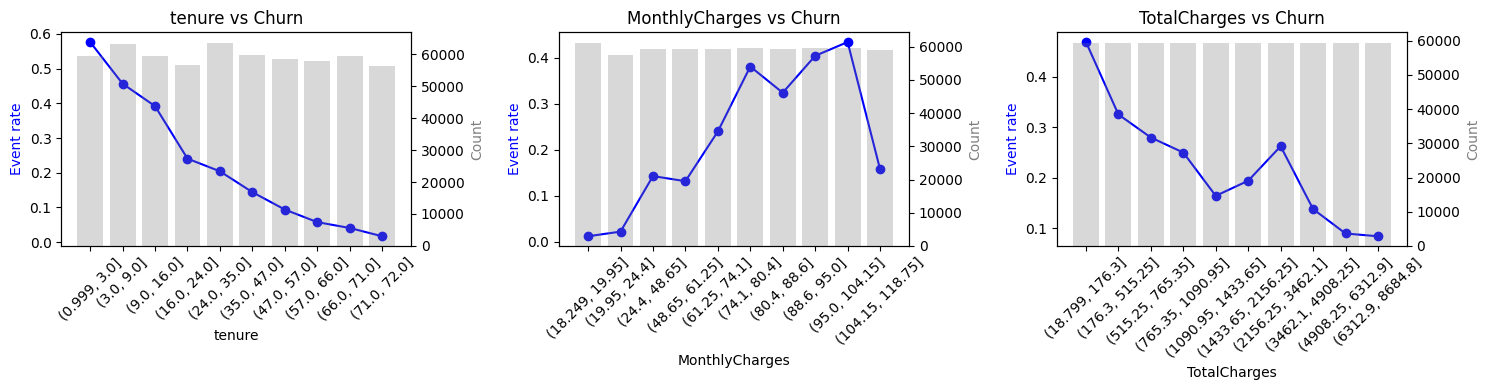

In [20]:
def plot_continuous_event_rate_multi_row(df, features, target, n_bins=10, show_count=True, n_cols=3):
    
    n_features = len(features)
    n_rows = (n_features + n_cols - 1) // n_cols  
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
    axes = axes.flatten()
    
    for i, feature in enumerate(features):
        df['bin'] = pd.qcut(df[feature], q=n_bins, duplicates='drop')
        stats = df.groupby('bin')[target].agg(['mean','count']).reset_index()
        
        ax1 = axes[i]
        ax1.plot(stats['bin'].astype(str), stats['mean'], marker='o', color='blue')
        ax1.set_xlabel(feature)
        ax1.set_ylabel('Event rate', color='blue')
        ax1.tick_params(axis='x',rotation=45)
        ax1.set_title(f'{feature} vs {target}')
        
        if show_count:
            ax2 = ax1.twinx()
            ax2.bar(stats['bin'].astype(str), stats['count'], alpha=0.3, color='grey')
            ax2.set_ylabel('Count', color='grey')
    
    
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
    df.drop(columns=['bin'], inplace=True)

plot_continuous_event_rate_multi_row(train, nums_cols, target='Churn', n_bins=10, n_cols=3)

# Numerical Features - Local ROC-AUC Contribution

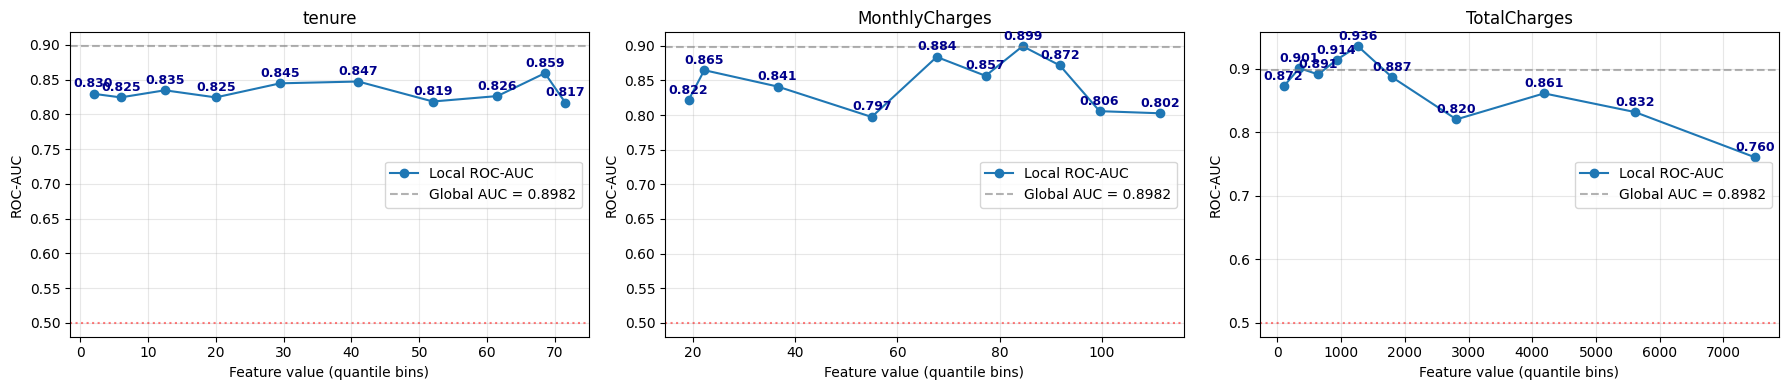

In [21]:
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

def numerical_local_auc_contribution(
    X: pd.DataFrame,
    y: pd.Series,
    numerical_features: list,
    model,
    n_splits: int = 5,
    n_bins: int = 10,
    random_state: int = 42,
    plot: bool = True,
    y_col: str = "y"
):

    # ---------- Step 1: OOF prediction ----------
    oof_pred = np.zeros(len(X))
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr = y.iloc[tr_idx]

        model.fit(X_tr, y_tr)
        oof_pred[val_idx] = model.predict_proba(X_val)[:, 1]

    global_auc = roc_auc_score(y, oof_pred)

    base_df = pd.DataFrame({
        y_col: y.values,
        "pred": oof_pred
    })

    results = {}

    # ---------- Step 2: Per-feature local AUC ----------
    for feat in numerical_features:
        df = base_df.copy()
        df["feature"] = X[feat].values

        df["bin"] = pd.qcut(df["feature"], q=n_bins, duplicates="drop")

        rows = []
        for b, g in df.groupby("bin"):
            if g[y_col].nunique() < 2:
                local_auc = np.nan
            else:
                local_auc = roc_auc_score(g[y_col], g["pred"])
            rows.append({
                "bin": b,
                "bin_mid": (b.left + b.right) / 2,
                "local_auc": local_auc,
                "auc_drop": global_auc - local_auc if not np.isnan(local_auc) else np.nan,
                "sample_count": len(g)
            })

        results[feat] = pd.DataFrame(rows)

    # ---------- Step 3: Plot all features ----------
    if plot:
        n_feats = len(numerical_features)
        n_cols = 3
        n_rows = (n_feats + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
        axes = axes.flatten()

        for i, feat in enumerate(numerical_features):
            out = results[feat]
            ax = axes[i]

            ax.plot(out["bin_mid"], out["local_auc"], marker="o", label="Local ROC-AUC")

            for x, y_val in zip(out["bin_mid"], out["local_auc"]):
                if not np.isnan(y_val):
                    ax.text(
                        x, y_val + 0.005,      
                        f"{y_val:.3f}",        
                        ha='center', va='bottom', 
                        fontsize=9, color='darkblue',
                        fontweight='bold'
                    )
            
            ax.axhline(global_auc, linestyle="--", color="gray", alpha=0.6,
                       label=f"Global AUC = {global_auc:.4f}")
            ax.axhline(0.5, linestyle=":", color="red", alpha=0.5)
            ax.set_title(feat)
            ax.set_xlabel("Feature value (quantile bins)")
            ax.set_ylabel("ROC-AUC")
            ax.grid(alpha=0.3)
            ax.legend()

        
        for j in range(i+1, len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()

    return results

results = numerical_local_auc_contribution(
    X=train[nums_cols],
    y=train["Churn"],
    numerical_features=nums_cols,
    model=LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbose=-1
    ),
    n_bins=10,
    plot=True,
    y_col='y'
)

# Numerical Features - Decision Tree Discretization

In [22]:
from sklearn.tree import DecisionTreeClassifier

def find_optimal_bins(df, feature, target='Churn', max_leaf_nodes=10):
    
    X = df[[feature]].values
    y = df[target].values

    tree = DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes,min_samples_leaf=0.05,random_state=42)
    tree.fit(X, y)
    
    thresholds = tree.tree_.threshold
    thresholds = thresholds[thresholds != -2]
    thresholds = sorted(thresholds)

    bins = [-np.inf] + thresholds + [np.inf]

    print(f"{feature} optimal bins:")
    print(bins)

    return bins

tenure_bins = find_optimal_bins(train,'tenure')
MonthlyCharges_bins = find_optimal_bins(train,'MonthlyCharges')
TotalCharges_bins = find_optimal_bins(train,'TotalCharges')

tenure optimal bins:
[-inf, np.float64(2.5), np.float64(5.5), np.float64(8.5), np.float64(11.5), np.float64(17.5), np.float64(32.5), np.float64(43.5), np.float64(56.5), np.float64(70.5), inf]
MonthlyCharges optimal bins:
[-inf, np.float64(23.975000381469727), np.float64(26.824999809265137), np.float64(51.27499961853027), np.float64(68.9749984741211), np.float64(80.7750015258789), np.float64(92.9749984741211), np.float64(96.9749984741211), np.float64(102.92499923706055), np.float64(106.9749984741211), inf]
TotalCharges optimal bins:
[-inf, np.float64(78.4749984741211), np.float64(198.0500030517578), np.float64(463.5749969482422), np.float64(920.2250061035156), np.float64(1244.5499877929688), np.float64(1421.9249877929688), np.float64(2069.5), np.float64(3243.9000244140625), np.float64(4283.5), inf]


# Categorical Features - CV Rank Consistency Probe

In [23]:
from sklearn.model_selection import StratifiedKFold
from scipy.stats import rankdata, spearmanr

def cv_safe_rank_consistency_single(
    X: pd.DataFrame,
    y: pd.Series,
    cat_col: str,
    n_splits: int = 5,
    random_state: int = 42
):
    """
    CV-safe Categorical Rank Consistency Probe (single feature)
    """
    skf = StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=True)
    oof_rank = np.zeros(len(X))

    global_mean = y.mean()

    for train_idx, val_idx in skf.split(X,y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr = y.iloc[train_idx]

        # category -> target mean (train only)
        cat_mean = (
            pd.concat([X_tr[[cat_col]], y_tr], axis=1)
            .groupby(cat_col)[y.name]
            .mean()
        )

        # map to validation (unseen -> global mean)
        mapped = X_val[cat_col].map(cat_mean).fillna(global_mean)

        # rank inside validation fold
        oof_rank[val_idx] = rankdata(mapped)

    # rank y globally
    y_rank = rankdata(y)

    spearman_corr = spearmanr(oof_rank, y_rank).correlation
    return spearman_corr

def cv_safe_rank_consistency_multi(
    X: pd.DataFrame,
    y: pd.Series,
    cat_cols: list,
    n_splits: int = 5,
    random_state: int = 42
):
    """
    CV-safe Categorical Rank Consistency Probe (multiple features)
    """
    results = {}

    for col in cat_cols:
        score = cv_safe_rank_consistency_single(
            X=X,
            y=y,
            cat_col=col,
            n_splits=n_splits,
            random_state=random_state
        )
        results[col] = score

    return (
        pd.DataFrame
        .from_dict(results, orient="index", columns=["cv_rank_consistency"])
        .sort_values("cv_rank_consistency", ascending=False)
    )


rank_probe_df = cv_safe_rank_consistency_multi(
    X=train,
    y=train["Churn"],
    cat_cols=cate_cols,
    n_splits=5
)

print(rank_probe_df)

                  cv_rank_consistency
Contract                     0.420728
PaymentMethod                0.401317
InternetService              0.389655
OnlineSecurity               0.386983
TechSupport                  0.379271
OnlineBackup                 0.341667
DeviceProtection             0.326426
PaperlessBilling             0.242278
StreamingMovies              0.217604
StreamingTV                  0.215509
Partner                      0.198660
Dependents                   0.192940
SeniorCitizen                0.132656
MultipleLines                0.101773
PhoneService                 0.015101
gender                       0.005937


# Numerical Features - Transform

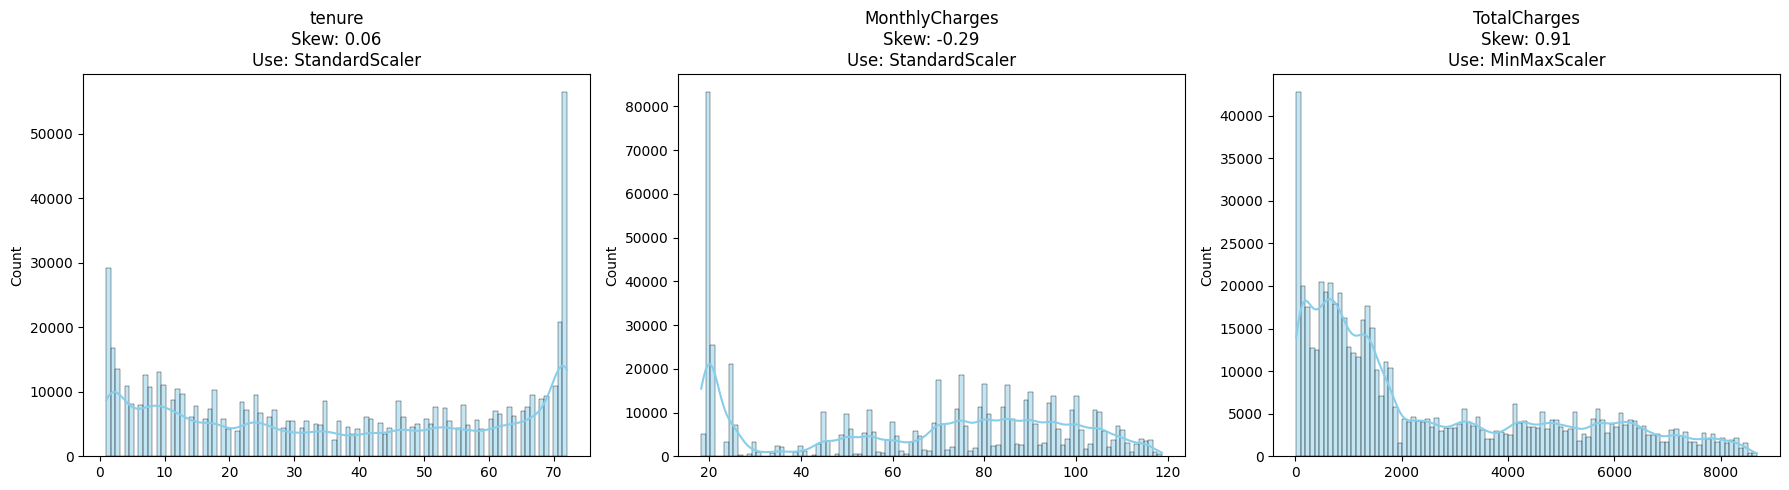

          feature  skewness      suggestion
0          tenure  0.063050  StandardScaler
1  MonthlyCharges -0.289485  StandardScaler
2    TotalCharges  0.909167    MinMaxScaler


In [24]:
from scipy.stats import skew
import math

def analyze_numeric_features(df, numeric_cols, plot=True):
    results = []
    n_cols = len(numeric_cols)
    
    cols_per_row = 3
    n_rows = math.ceil(n_cols / cols_per_row)

    if plot:
        fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(18, 5 * n_rows))
        axes = axes.flatten()  #

    for i, col in enumerate(numeric_cols):
        data = df[col].dropna()
        skewness = skew(data)

        if abs(skewness) < 0.5:
            suggestion = "StandardScaler"
        elif abs(skewness) < 1.0:
            suggestion = "MinMaxScaler"
        elif abs(skewness) < 2.0:
            suggestion = "RobustScaler"
        else:
            suggestion = "Box-Cox / Yeo-Johnson"

        results.append({
            "feature": col,
            "skewness": skewness,
            "suggestion": suggestion
        })

        if plot:
            ax = axes[i]
            sns.histplot(data, kde=True, bins=100, color='skyblue', ax=ax)
            ax.set_title(f"{col}\nSkew: {skewness:.2f}\nUse: {suggestion}", fontsize=12)
            ax.set_xlabel("")
            ax.set_ylabel("Count")

    if plot:
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return pd.DataFrame(results)


result_df = analyze_numeric_features(train, nums_cols)
print(result_df)

In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import PowerTransformer

def scale_selected_features(train_df, test_df, feature_suggestions):
    
     # copy
    scaled_train = train_df.copy()
    scaled_test = test_df.copy()
    
    for suggestion, group in feature_suggestions.groupby('suggestion'):
        features = group['feature'].tolist()
        
        if suggestion == "StandardScaler (Z-score)":
            scaler = StandardScaler()
            suffix = "_std"
        elif suggestion == "MinMaxScaler":
            scaler = MinMaxScaler()
            suffix = "_minmax"
        elif suggestion == "RobustScaler":
            scaler = RobustScaler()
            suffix = "_robust"
        elif suggestion == "Box-Cox / Yeo-Johnson":
            scaler = PowerTransformer(method='box-cox')  # Box-Cox >0
            suffix = "_power"
        else:
            scaler = RobustScaler()
            suffix = "_scaled"

        new_features_names = [f"{feat}{suffix}" for feat in features]
        # fit on train
        scaler.fit(train_df[features])
        # transform train/test
        scaled_train[new_features_names] = scaler.transform(train_df[features])
        scaled_test[new_features_names] = scaler.transform(test_df[features])
    
    return scaled_train, scaled_test

train, test = scale_selected_features(train, test, result_df)

# Numerical Features - Inverse Residual Feature Engineering

Step 1: Other features → Predict this feature

Step 2: Calculate residual

Step 3: Standardize residual

Step 4: Generate anomaly features

Step 5: Add these new features back to the data

In [26]:
import lightgbm as lgb

def build_inverse_feature_pipeline(train_df, test_df, features_to_analyze, target_col='Churn'):
    train_work = train_df.copy()
    test_work = test_df.copy()
    
    cat_cols = train_work.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        codes, uniques = pd.factorize(train_work[col])
        train_work[col] = codes
        mapping = {val: i for i, val in enumerate(uniques)}
        test_work[col] = test_work[col].map(mapping).fillna(-1).astype(int)

    train_final = train_df.copy()
    test_final = test_df.copy()

    for col in features_to_analyze:
        print(f" Analyzing {col}...")
        
        current_drop = [c for c in [col, target_col] if c in train_work.columns]
        X_train = train_work.drop(columns=current_drop)
        y_train = train_work[col]
        
        used_features = X_train.columns.tolist()
        
        model = lgb.LGBMRegressor(n_estimators=300,learning_rate=0.05,max_depth=6, verbose=-1, random_state=42)
        model.fit(X_train, y_train)

        train_preds = model.predict(X_train)
        train_resid = y_train - train_preds
        m, s = train_resid.mean(), train_resid.std()

        X_test = test_work[used_features] 
        y_test = test_work[col]

        test_preds = model.predict(X_test)
        test_resid = y_test - test_preds

        train_z = (train_resid - m) / s
        
        train_final[f'{col}_resid_zscore'] = train_z
        train_final[f'{col}_anomaly_flag'] = 0
        train_final.loc[train_final[f'{col}_resid_zscore'] > 1.5, f'{col}_anomaly_flag'] = 1
        train_final.loc[train_final[f'{col}_resid_zscore'] < -1.5, f'{col}_anomaly_flag'] = -1
        train_final[f'{col}_resid'] = train_resid
        train_final[f'{col}_resid_abs'] = np.abs(train_resid)
        train_final[f'{col}_strong_anomaly'] = (np.abs(train_z) > 2).astype(int)
        
        test_z  = (test_resid - m) / s
        test_final[f'{col}_resid_zscore'] = test_z
        test_final[f'{col}_anomaly_flag'] = 0
        test_final.loc[test_final[f'{col}_resid_zscore'] > 1.5, f'{col}_anomaly_flag'] = 1
        test_final.loc[test_final[f'{col}_resid_zscore'] < -1.5, f'{col}_anomaly_flag'] = -1
        test_final[f'{col}_resid']  = test_resid
        test_final[f'{col}_resid_abs']  = np.abs(test_resid)
        test_final[f'{col}_strong_anomaly']  = (np.abs(test_z) > 2).astype(int)
        
    return train_final, test_final

train, test = build_inverse_feature_pipeline(train, test, ['MonthlyCharges', 'tenure','TotalCharges'])

 Analyzing MonthlyCharges...
 Analyzing tenure...
 Analyzing TotalCharges...



 Visualizing MonthlyCharges inverse features


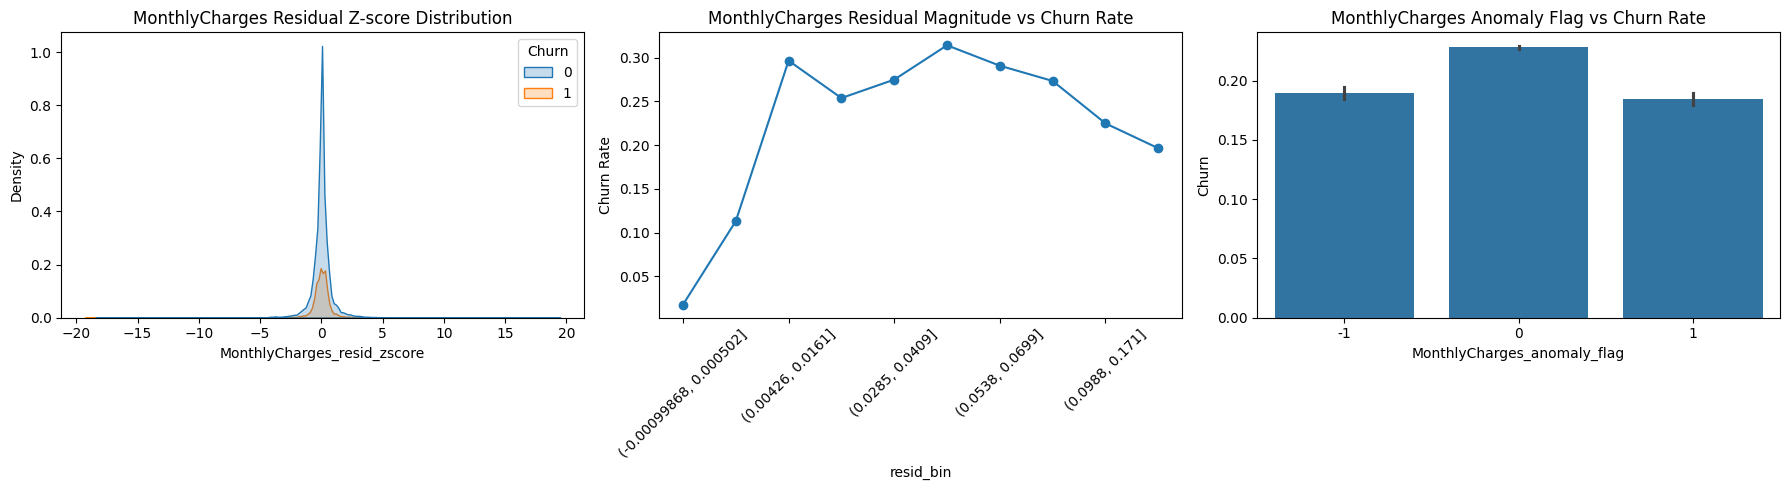


 Visualizing tenure inverse features


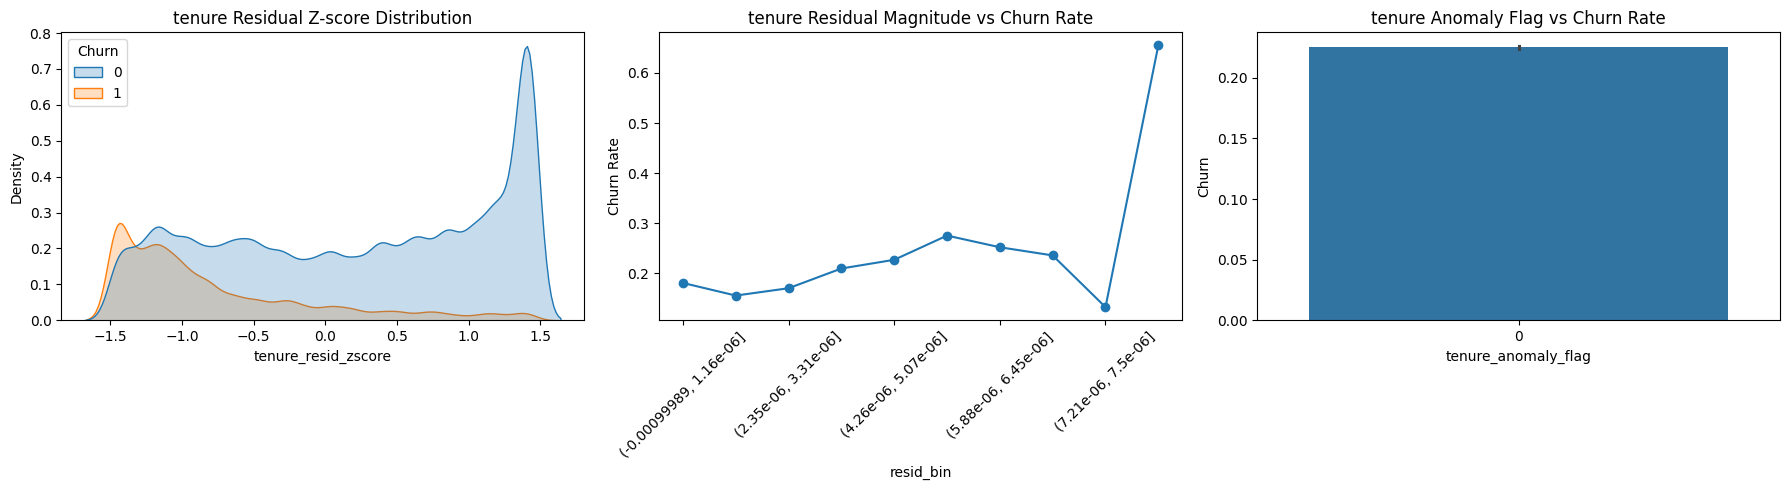


 Visualizing TotalCharges inverse features


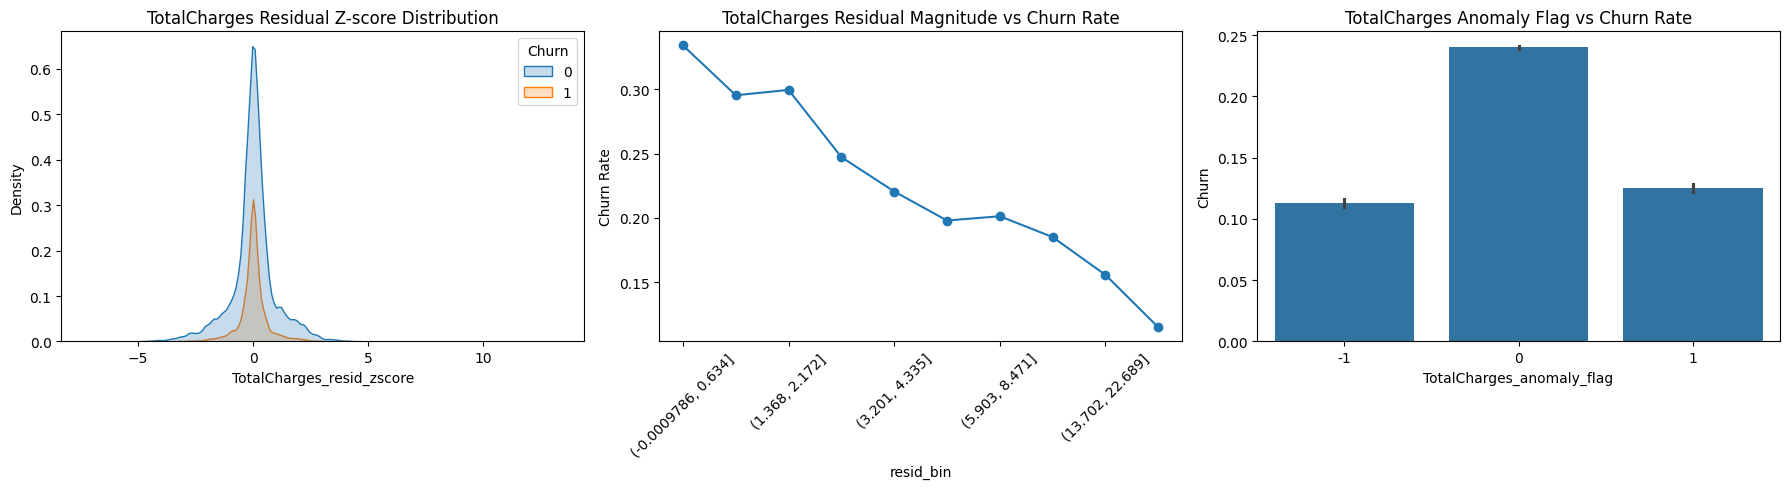

In [27]:
def visualize_inverse_features(train_df, features_to_visualize, target_col='Churn'):
    
    df = train_df.copy()
    
    for col in features_to_visualize:
        print(f"\n Visualizing {col} inverse features")

        resid_z = f"{col}_resid_zscore"
        resid_abs = f"{col}_resid_abs"
        anomaly = f"{col}_anomaly_flag"

        fig, axes = plt.subplots(1, 3, figsize=(18,5))

        # 1 Residual Z-score distribution
        sns.kdeplot(
            data=df,
            x=resid_z,
            hue=target_col,
            fill=True,
            ax=axes[0]
        )
        axes[0].set_title(f"{col} Residual Z-score Distribution")


        # 2 Residual magnitude vs churn rate
        temp = df.copy()
        temp["resid_bin"] = pd.qcut(temp[resid_abs], 10, duplicates='drop')

        churn_rate = temp.groupby("resid_bin")[target_col].mean()

        churn_rate.plot(
            kind='line',
            marker='o',
            ax=axes[1]
        )

        axes[1].set_title(f"{col} Residual Magnitude vs Churn Rate")
        axes[1].set_ylabel("Churn Rate")
        axes[1].tick_params(axis='x', rotation=45)


        # 3 anomaly flag vs churn rate
        sns.barplot(
            x=anomaly,
            y=target_col,
            data=df,
            ax=axes[2]
        )

        axes[2].set_title(f"{col} Anomaly Flag vs Churn Rate")

        plt.tight_layout()
        plt.show()

visualize_inverse_features(train,['MonthlyCharges','tenure','TotalCharges'])

In [ ]:
#resid_zscore_features = ["tenure_resid_zscore","TotalCharges_resid_zscore","MonthlyCharges_resid",
#                        "tenure_resid_abs","TotalCharges_resid_abs","MonthlyCharges_resid_abs"]
#plot_kde_by_label(train, resid_zscore_features, LABEL)

# Create Feature from Derive_binary_formula

In [30]:
def apply_risk_scoring(train_df, test_df, report_df, categorical_cols, continuous_cols):
    
    intercept = report_df[report_df['Feature'] == '(Intercept)']['Coefficient'].values[0]
    coef_df = report_df[report_df['Feature'] != '(Intercept)']
    
    def prepare_data(df):
        df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
        
        scaler = StandardScaler()
        df_encoded[continuous_cols] = scaler.fit_transform(df_encoded[continuous_cols])
        return df_encoded

    train_proc = prepare_data(train_df)
    test_proc = prepare_data(test_df)
    
    train_score = np.full(len(train_proc), intercept)
    test_score = np.full(len(test_proc), intercept)
    
    for _, row in coef_df.iterrows():
        feat = row['Feature']
        coef = row['Coefficient']
        
        if feat in train_proc.columns:
            train_score += train_proc[feat] * coef
        if feat in test_proc.columns:
            test_score += test_proc[feat] * coef
            
    train_df['risk_score'] = train_score
    test_df['risk_score'] = test_score
    
    print(f" Add 'risk_score' Feature。")
    return train_df, test_df


train, test = apply_risk_scoring(
    train_df=train, 
    test_df=test, 
    report_df=report, 
    categorical_cols=cate_cols, 
    continuous_cols=nums_cols
)

 Add 'risk_score' Feature。


# Create Features from Rolling + Decision Stump

In [35]:
def decision_features(df, train_stats=None):
    new_df = df.copy()
    
    # thresholds
    thresholds = {
         "MonthlyCharges": 68.9749, "TotalCharges": 920.2250,"tenure":17.50}
    for feat, thresh in thresholds.items():
        new_df[f"{feat}_threshold"] = (new_df[feat] >= thresh).astype(int)
        # how far with thresholds
        new_df[f"{feat}_dist_thresh"] = new_df[feat] - thresh

    # signal features weight
    diff_weights = {
        "MonthlyCharges": 0.2645, "TotalCharges": -0.1873,"tenure":-0.356813}
    for feat, weight in diff_weights.items():
        new_df[f"{feat}_abs_diff"] = new_df[feat] * weight

    # how far with mean
    for feat in thresholds.keys():
        if train_stats and feat in train_stats:
            m = train_stats[feat]['mean']
            s = train_stats[feat]['std']
        else:
            m = new_df[feat].mean()
            s = new_df[feat].std()
            
        new_df[f"{feat}_far_mean"] = (new_df[feat] - m) / (s + 1e-5)
        
    return new_df

train = decision_features(train)
test = decision_features(test)

# Create Features from Decision Tree Discretization

In [36]:
def create_custom_bins(train,test,col_configs):
    for col,bins in col_configs.items():
        actual_bins = sorted(list(set([-np.inf] + bins + [np.inf])))

        labels = range(1,len(actual_bins))
        train[f"{col}_custom_bin"] = pd.cut(train[col],bins=actual_bins,labels=labels).astype(int)
        test[f"{col}_custom_bin"] = pd.cut(test[col],bins=actual_bins,labels=labels).astype(int)

    return train,test

custom_configs = {
    "tenure":[2.5,5.5,8.5,11.5,17.5,32.5,43.5,56.5,70.5],
    "MonthlyCharges":[23.97,26.82,51.27,68.97,80.77,92.97,96.97,102.92,106.97],
    "TotalCharges":[78.47,198.05,463.57,920.22,1244.54,1421.92,2069.5,3243.90,4283.5]}

train,test = create_custom_bins(train,test,custom_configs)

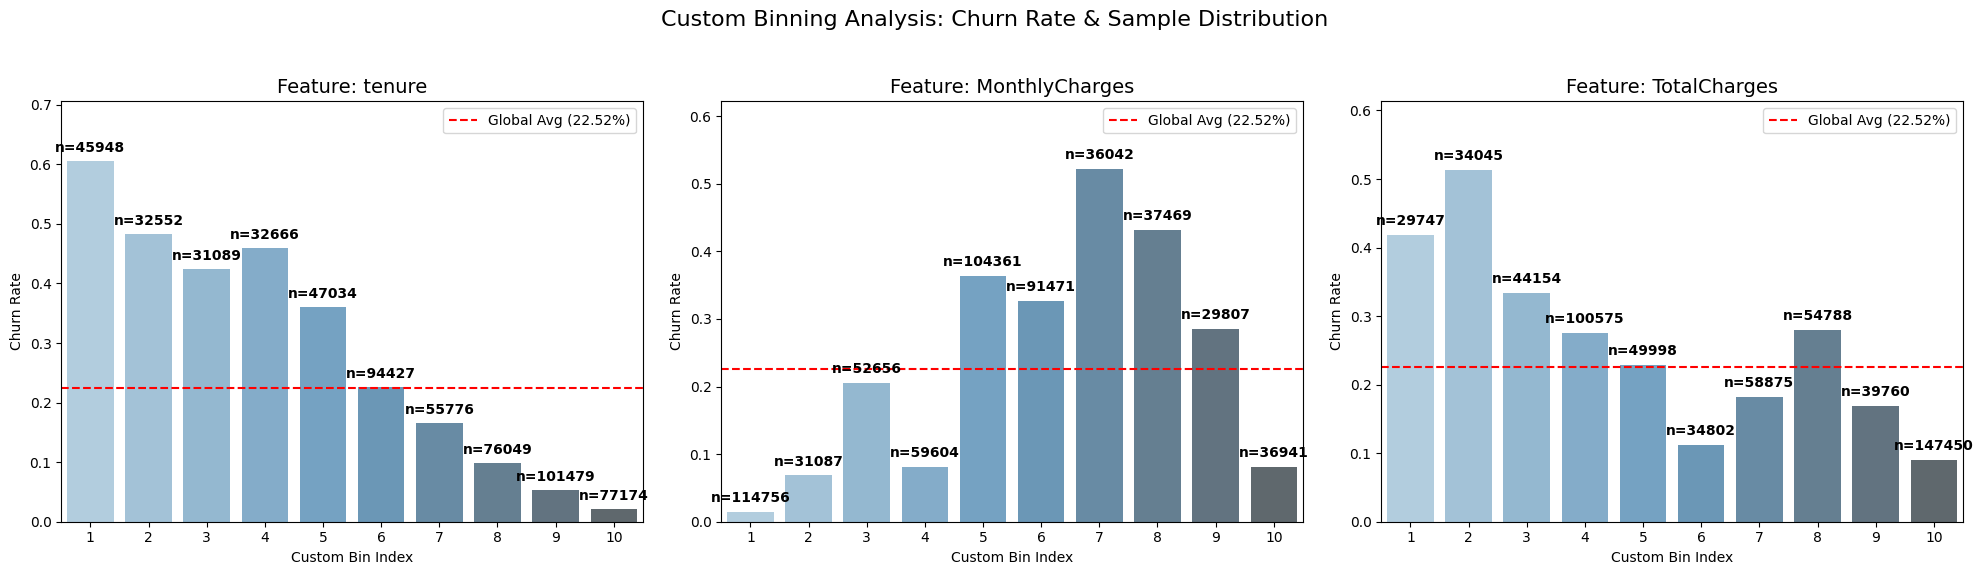

In [37]:
def plot_bin_analysis(df, col_configs, target='Churn'):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Custom Binning Analysis: Churn Rate & Sample Distribution', fontsize=16)

    for i, (col, bins) in enumerate(col_configs.items()):
        bin_col = f"{col}_custom_bin"
        
        stats = df.groupby(bin_col)[target].agg(['count', 'mean']).reset_index()
        
        sns.barplot(ax=axes[i], data=stats, x=bin_col, y='mean', palette='Blues_d', alpha=0.8)
        
        for index, row in stats.iterrows():
            axes[i].text(index, row['mean'] + 0.01, f"n={int(row['count'])}", 
                         ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        global_mean = df[target].mean()
        axes[i].axhline(global_mean, color='red', linestyle='--', label=f'Global Avg ({global_mean:.2%})')
        
        axes[i].set_title(f'Feature: {col}', fontsize=14)
        axes[i].set_ylabel('Churn Rate')
        axes[i].set_xlabel('Custom Bin Index')
        axes[i].set_ylim(0, stats['mean'].max() + 0.1) 
        axes[i].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_bin_analysis(train, custom_configs)

# Create Features Rank

In [38]:
def rank_transform_fast(train, test, feature_list):
    train_df = train.copy()
    test_df = test.copy()
    
    for col in feature_list:
        train_values = np.sort(train_df[col].values)
        n = len(train_values)
        
        train_df[f"{col}_rank"] = (train_df[col].rank(method='max', pct=True) * 100).round(0).astype(int)
        
        indices = np.searchsorted(train_values, test_df[col].values, side='right')
        test_df[f"{col}_rank"] = ((indices / n) * 100).round(0).astype(int)
        
    return train_df, test_df

target_features = ['tenure','MonthlyCharges', 'TotalCharges']

train, test = rank_transform_fast(train, test, target_features)

In [39]:
def transform_rank_to_decile(df, rank_cols):
    new_df = df.copy()
    
    bins = [-1] + list(range(10, 110, 10))
    
    labels = [f'D{i}' for i in range(1, 11)]
    
    for col in rank_cols:
        if col in new_df.columns:
            new_name = col.replace('_rank', '_decile')
            new_df[new_name] = pd.cut(new_df[col], bins=bins, labels=labels).astype(str)
            
    return new_df


target_rank_features = ['tenure_rank','MonthlyCharges_rank', 'TotalCharges_rank']

train = transform_rank_to_decile(train, target_rank_features)
test = transform_rank_to_decile(test, target_rank_features)

# Create Digit Features

In [40]:
def apply_digit_features(df, config_dict):
    
    df = df.copy()
    new_features = []
    
    for col, k_range in config_dict.items():
        if col not in df.columns:
            print(f"Warning: {col} not in DataFrame，skip...")
            continue
            
        for k in k_range:
            feature_name = f'{col}_d{k}'
            
            digit_series = (np.floor(df[col].astype(float) * (10**k) + 1e-9) % 10)
            
            df[feature_name] = digit_series.fillna(-1).astype("int8")
            new_features.append(feature_name)
            
    print(f"Add {len(new_features)} digit features。")
    return df, new_features


configs = {
    'MonthlyCharges': range(-1, 2),  
    'TotalCharges':   range(-3, 3),  
   }

train, digit_cols = apply_digit_features(train, configs)
test, _ = apply_digit_features(test, configs)

Add 9 digit features。
Add 9 digit features。


# Create Feature Nums To Cate

In [41]:
def nums_to_cate(df):
    df["tenure_cate"] = df["tenure"].astype(object)
    return df

train = nums_to_cate(train)
test = nums_to_cate(test)

# Create Feature Combinations

In [42]:
extra_cate_features = ["tenure_custom_bin","MonthlyCharges_custom_bin","TotalCharges_custom_bin","tenure_rank","MonthlyCharges_rank",
                       "TotalCharges_rank","TotalCharges_decile","MonthlyCharges_decile","tenure_decile","tenure_cate"]
cate_cols.extend(extra_cate_features)

In [43]:
rank_probe_df = cv_safe_rank_consistency_multi(
    X=train,
    y=train["Churn"],
    cat_cols=cate_cols,
    n_splits=5
)

print(rank_probe_df)

                           cv_rank_consistency
tenure_cate                           0.431654
tenure_rank                           0.430438
tenure_custom_bin                     0.424013
Contract                              0.420728
tenure_decile                         0.419252
PaymentMethod                         0.401317
MonthlyCharges_rank                   0.390438
InternetService                       0.389655
OnlineSecurity                        0.386983
TechSupport                           0.379271
MonthlyCharges_custom_bin             0.378379
MonthlyCharges_decile                 0.347640
OnlineBackup                          0.341667
DeviceProtection                      0.326426
TotalCharges_rank                     0.310187
TotalCharges_custom_bin               0.267462
TotalCharges_decile                   0.253843
PaperlessBilling                      0.242278
StreamingMovies                       0.217604
StreamingTV                           0.215509
Partner      

In [44]:
from itertools import combinations
nums_bin_features = ["tenure_cate","Contract","PaymentMethod","MonthlyCharges_rank","InternetService","OnlineSecurity","TechSupport"]
comb_features = nums_bin_features

def combine_features(train_df, test_df, feature_list, degree=2, sep="_"):
    new_features = []

    for comb in combinations(feature_list, degree):
        col_name = sep.join(comb)
        print(f"Create {col_name}")
        
        train_df[col_name] = train_df[list(comb)].astype(str).agg(sep.join, axis=1)
        test_df[col_name]  = test_df[list(comb)].astype(str).agg(sep.join, axis=1)
        
        new_features.append(col_name)

    return train_df, test_df, new_features

train, test, pair_feats = combine_features(train_df=train,test_df=test,feature_list=comb_features,degree=2)
print("Create {} Pair Features".format(len(pair_feats)))

Create tenure_cate_Contract
Create tenure_cate_PaymentMethod
Create tenure_cate_MonthlyCharges_rank
Create tenure_cate_InternetService
Create tenure_cate_OnlineSecurity
Create tenure_cate_TechSupport
Create Contract_PaymentMethod
Create Contract_MonthlyCharges_rank
Create Contract_InternetService
Create Contract_OnlineSecurity
Create Contract_TechSupport
Create PaymentMethod_MonthlyCharges_rank
Create PaymentMethod_InternetService
Create PaymentMethod_OnlineSecurity
Create PaymentMethod_TechSupport
Create MonthlyCharges_rank_InternetService
Create MonthlyCharges_rank_OnlineSecurity
Create MonthlyCharges_rank_TechSupport
Create InternetService_OnlineSecurity
Create InternetService_TechSupport
Create OnlineSecurity_TechSupport
Create 21 Pair Features


In [45]:
triple_bin_features = ["MonthlyCharges_custom_bin","OnlineBackup","DeviceProtection","TotalCharges_rank","PaperlessBilling","StreamingMovies","StreamingTV"]
train, test, triple_feats = combine_features(train_df=train,test_df=test,feature_list=triple_bin_features,degree=3)
print("Create {} Triple Features".format(len(triple_feats)))

Create MonthlyCharges_custom_bin_OnlineBackup_DeviceProtection
Create MonthlyCharges_custom_bin_OnlineBackup_TotalCharges_rank
Create MonthlyCharges_custom_bin_OnlineBackup_PaperlessBilling
Create MonthlyCharges_custom_bin_OnlineBackup_StreamingMovies
Create MonthlyCharges_custom_bin_OnlineBackup_StreamingTV
Create MonthlyCharges_custom_bin_DeviceProtection_TotalCharges_rank
Create MonthlyCharges_custom_bin_DeviceProtection_PaperlessBilling
Create MonthlyCharges_custom_bin_DeviceProtection_StreamingMovies
Create MonthlyCharges_custom_bin_DeviceProtection_StreamingTV
Create MonthlyCharges_custom_bin_TotalCharges_rank_PaperlessBilling
Create MonthlyCharges_custom_bin_TotalCharges_rank_StreamingMovies
Create MonthlyCharges_custom_bin_TotalCharges_rank_StreamingTV
Create MonthlyCharges_custom_bin_PaperlessBilling_StreamingMovies
Create MonthlyCharges_custom_bin_PaperlessBilling_StreamingTV
Create MonthlyCharges_custom_bin_StreamingMovies_StreamingTV
Create OnlineBackup_DeviceProtection_Tot

In [46]:
def engineering_weak_features(df):
    new_df = df.copy()
    
    conditions = [
        (new_df['Partner'] == 'No') & (new_df['Dependents'] == 'No'),
        (new_df['Partner'] == 'Yes') & (new_df['Dependents'] == 'No'),
        (new_df['Partner'] == 'No') & (new_df['Dependents'] == 'Yes'),
        (new_df['Partner'] == 'Yes') & (new_df['Dependents'] == 'Yes')
    ]
    choices = ['Single', 'Partner_Only', 'Children_Only', 'Full_Family']
    new_df['Household_Type'] = pd.Series(
        pd.NA, index=new_df.index
    ).mask(conditions[0], choices[0]).mask(conditions[1], choices[1]).mask(conditions[2], choices[2]).mask(conditions[3], choices[3])

    new_df['Phone_Utility'] = 'No_Phone'
    new_df.loc[new_df['PhoneService'] == 'Yes', 'Phone_Utility'] = 'Single_Line'
    new_df.loc[new_df['MultipleLines'] == 'Yes', 'Phone_Utility'] = 'Multiple_Lines'

    
    new_df['Is_Senior_Month_to_Month'] = ((new_df['SeniorCitizen'] == 1) & 
                                          (new_df['Contract'] == 'Month-to-month')).astype(int)

    drop_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines']
    new_df = new_df.drop(columns=[col for col in drop_cols if col in new_df.columns])

    return new_df

train = engineering_weak_features(train)
test = engineering_weak_features(test)

# Ｗeight of Evidence

In [47]:
from category_encoders import WOEEncoder

def WoE(train_df, test_df, features, target_col, n_splits=5):
    train_final = train_df.copy()
    test_final = test_df.copy()
    
    woe_cols = [f"{col}_woe" for col in features]
    for col in woe_cols:
        train_final[col] = 0.0
        test_final[col] = 0.0
        
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        
    for train_idx, valid_idx in skf.split(train_df, train_df[target_col]):
        
        df_train_fold = train_df.iloc[train_idx]
        df_valid_fold = train_df.iloc[valid_idx]
        
        
        encoder = WOEEncoder(cols=features)
        encoder.fit(X=df_train_fold[features], y=df_train_fold[target_col])
        
        
        encoded_valid = encoder.transform(df_valid_fold[features])
        train_final.iloc[valid_idx, train_final.columns.get_indexer(woe_cols)] = encoded_valid.values

    
    final_encoder = WOEEncoder(cols=features)
    final_encoder.fit(train_df[features], train_df[target_col])
    test_final[woe_cols] = final_encoder.transform(test_df[features]).values
    
    return train_final, test_final

woe_features = [col for col in train.columns if (train[col].dtype == "object" or train[col].nunique() < 10) and col != "Churn"]

train,test = WoE(train_df=train,test_df=test,features=woe_features,target_col='Churn')

In [48]:
def plot_woe_row(df, features):

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 5 * n_rows))
    axes = axes.flatten() 
    

    sns.set_style("whitegrid")
    
    for i, col in enumerate(features):
        woe_col = f"{col}_woe"
        
        plot_data = df[[col, woe_col]].drop_duplicates().sort_values(by=woe_col)
        
        sns.barplot(x=col, y=woe_col, data=plot_data, ax=axes[i], palette="Spectral")
        
        axes[i].set_title(f'WoE: {col}', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Weight of Evidence')
        axes[i].axhline(0, color='black', linestyle='--', linewidth=1.2)
        axes[i].tick_params(axis='x', rotation=45) 
        
        for p in axes[i].patches:
            axes[i].annotate(f'{p.get_height():.2f}', 
                             (p.get_x() + p.get_width() / 2., p.get_height()), 
                             ha='center', va='bottom', fontsize=10)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

#plot_woe_row(train, features=woe_features)

In [49]:
def create_woe_features(df,features):
    woe_cols = [f"{col}_woe" for col in features]
    # basic
    df["Total_Clinical_Weight"] = df[woe_cols].sum(axis=1)
    # scaler
    #minmax_scaler = MinMaxScaler()
    #df['Total_Weight_Scaled'] = minmax_scaler.fit_transform(df[['Total_Clinical_Weight']])
    #rb_scaler = RobustScaler()
    #df['Weight_Norm'] = rb_scaler.fit_transform(df[['Total_Clinical_Weight']])
    # statistics
    df["Max_WoE_Impact"] = df[woe_cols].max(axis=1)
    df["Mean_WoE"] = df[woe_cols].mean(axis=1)
    df["Std_WoE"] = df[woe_cols].std(axis=1)
    df["Median_WoE"] = df[woe_cols].median(axis=1)
    df["Abs_WoE_Sum"] = df[woe_cols].abs().sum(axis=1)
    # risk count
    df["Positive_Risk_Count"] = (df[woe_cols] > 0).sum(axis=1)
    df["High_Risk_Count"] = (df[woe_cols] > 0.5).sum(axis=1)
    df["Low_Risk_Count"]  = (df[woe_cols] < -0.5).sum(axis=1)
    pos = (df[woe_cols] > 0).sum(axis=1)
    neg = (df[woe_cols] < 0).sum(axis=1)
    df["Risk_Ratio"] = pos / (neg + 1)
    # order
    df["Top10_WoE_Sum"] = np.sort(df[woe_cols].values, axis=1)[:, -10:].sum(axis=1)
    return df

train = create_woe_features(train,features=woe_features)
test = create_woe_features(test,features=woe_features)

In [ ]:
#woe_features_list = [col for col in train.columns if '_woe' in col]
#extra_woe_features = ["Total_Clinical_Weight","Max_WoE_Impact","Mean_WoE",
#                      "Std_WoE","Median_WoE","Abs_WoE_Sum","Positive_Risk_Count","High_Risk_Count","Low_Risk_Count",
#                      "Risk_Ratio","Top10_WoE_Sum"]
#woe_features_list.extend(extra_woe_features)

#plot_kde_by_label(train, nums_cols=woe_features_list, label_col='Churn')

# PCA Analysis

In [50]:
pca_select_features = [col for col in train.columns if "_woe" in col and col != "Churn"]

print("Create {} PCA Select Features".format(len(pca_select_features)))

pca_select_features

Create 85 PCA Select Features


['SeniorCitizen_woe',
 'InternetService_woe',
 'OnlineSecurity_woe',
 'OnlineBackup_woe',
 'DeviceProtection_woe',
 'TechSupport_woe',
 'StreamingTV_woe',
 'StreamingMovies_woe',
 'Contract_woe',
 'PaperlessBilling_woe',
 'PaymentMethod_woe',
 'MonthlyCharges_anomaly_flag_woe',
 'MonthlyCharges_strong_anomaly_woe',
 'tenure_anomaly_flag_woe',
 'tenure_strong_anomaly_woe',
 'TotalCharges_anomaly_flag_woe',
 'TotalCharges_strong_anomaly_woe',
 'MonthlyCharges_threshold_woe',
 'TotalCharges_threshold_woe',
 'tenure_threshold_woe',
 'tenure_decile_woe',
 'MonthlyCharges_decile_woe',
 'TotalCharges_decile_woe',
 'TotalCharges_d-3_woe',
 'TotalCharges_d2_woe',
 'tenure_cate_woe',
 'tenure_cate_Contract_woe',
 'tenure_cate_PaymentMethod_woe',
 'tenure_cate_MonthlyCharges_rank_woe',
 'tenure_cate_InternetService_woe',
 'tenure_cate_OnlineSecurity_woe',
 'tenure_cate_TechSupport_woe',
 'Contract_PaymentMethod_woe',
 'Contract_MonthlyCharges_rank_woe',
 'Contract_InternetService_woe',
 'Contract

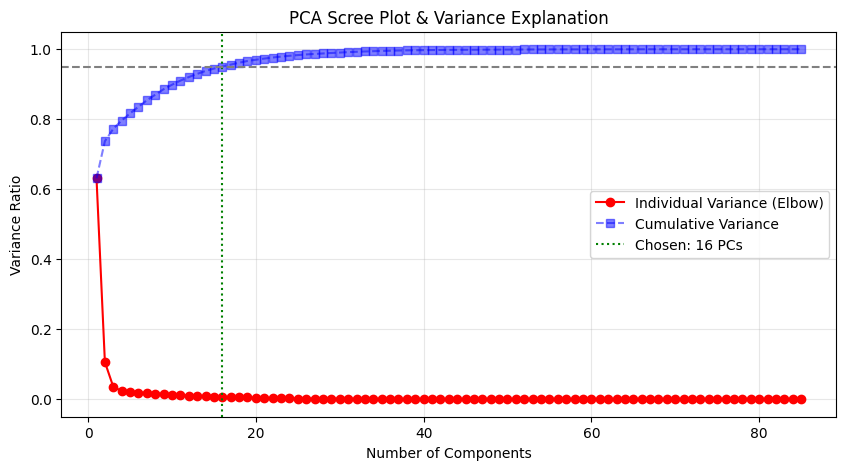

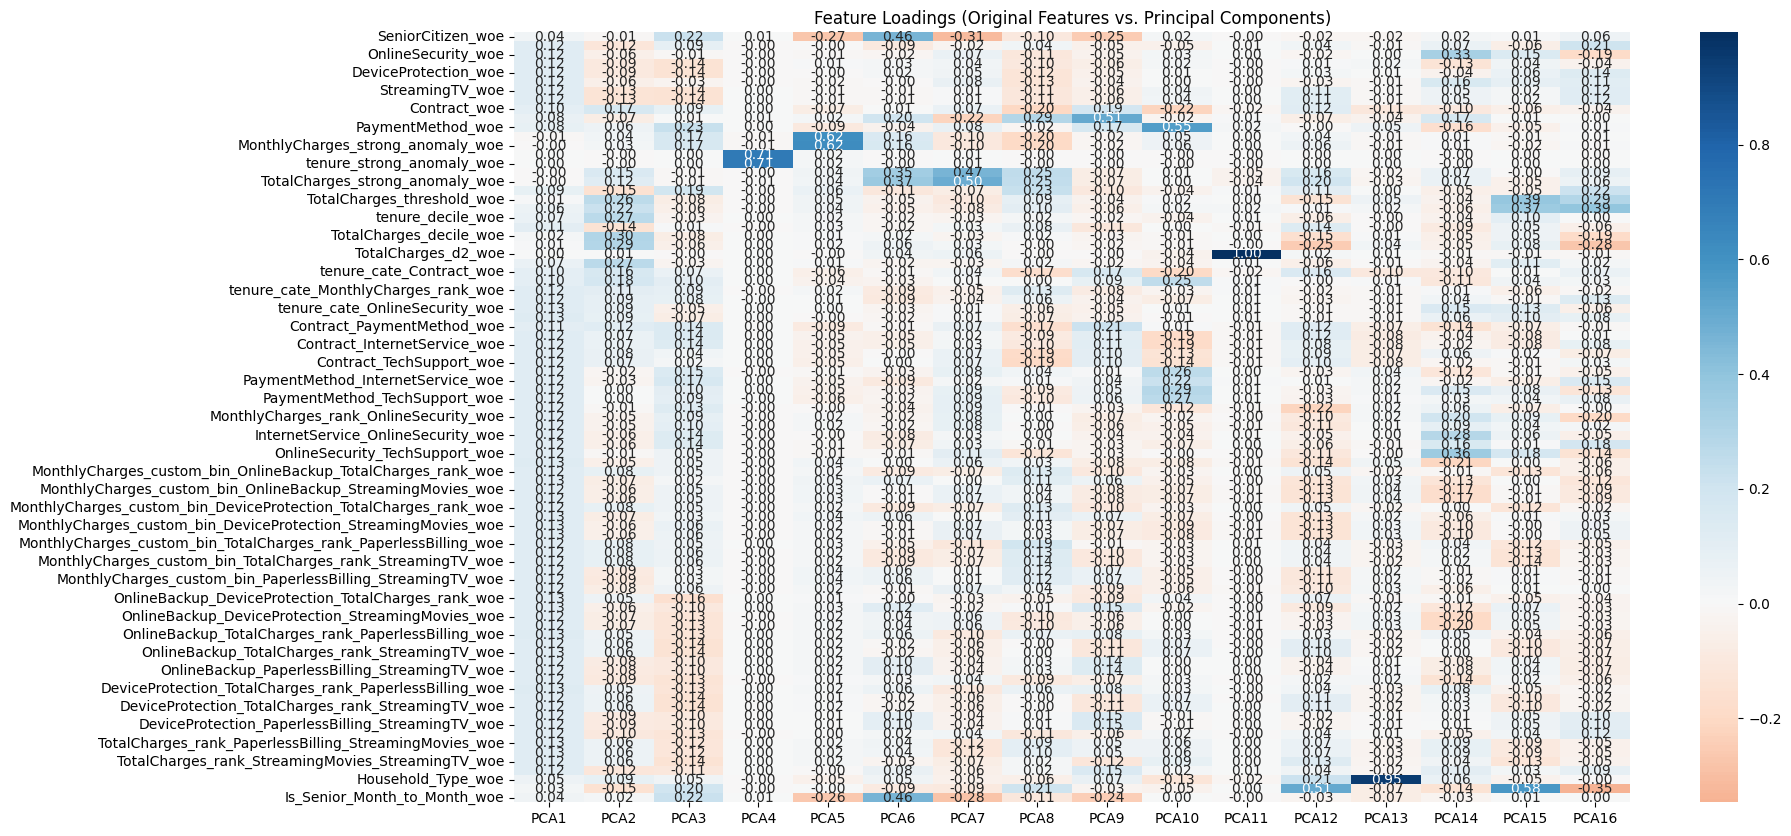

[*] Add 16 PCA Features。


In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def pca_optimized_pipeline(train_df, test_df, feature_cols, target_explained_variance=0.95):
    
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test) 

    
    pca_full = PCA()
    pca_full.fit(X_train_scaled)
    
    ind_var = pca_full.explained_variance_ratio_ 
    cum_var = np.cumsum(ind_var)                

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(ind_var) + 1), ind_var, 'ro-', label='Individual Variance (Elbow)')
    plt.plot(range(1, len(cum_var) + 1), cum_var, 'bs--', alpha=0.5, label='Cumulative Variance')
    
    n_components = np.argmax(cum_var >= target_explained_variance) + 1
    
    plt.axvline(x=n_components, color='g', linestyle=':', label=f'Chosen: {n_components} PCs')
    plt.axhline(y=target_explained_variance, color='gray', linestyle='--')
    plt.title('PCA Scree Plot & Variance Explanation')
    plt.xlabel('Number of Components')
    plt.ylabel('Variance Ratio')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    pca_final = PCA(n_components=n_components)
    train_pca_vals = pca_final.fit_transform(X_train_scaled)
    test_pca_vals = pca_final.transform(X_test_scaled)
    
    pc_columns = [f'PCA{i+1}' for i in range(n_components)]
    train_pca_df = pd.DataFrame(train_pca_vals, columns=pc_columns, index=train_df.index)
    test_pca_df = pd.DataFrame(test_pca_vals, columns=pc_columns, index=test_df.index)

    new_train_df = pd.concat([train_df, train_pca_df], axis=1)
    new_test_df = pd.concat([test_df, test_pca_df], axis=1)

    plt.figure(figsize=(18, min(len(feature_cols) * 0.4, 10)))
    loadings = pd.DataFrame(
        pca_final.components_.T, 
        columns=pc_columns, 
        index=feature_cols
    )
    sns.heatmap(loadings, annot=True, cmap='RdBu', center=0, fmt=".2f")
    plt.title('Feature Loadings (Original Features vs. Principal Components)')
    plt.show()
    
    print(f"[*] Add {n_components} PCA Features。")
    #print(f"[*] Total Explained Variance : {cum_var[n_components-1]:.4f}")

    return new_train_df, new_test_df, loadings, pca_final

train, test, loading_matrix, model = pca_optimized_pipeline(train, test, feature_cols=pca_select_features, target_explained_variance=0.95)

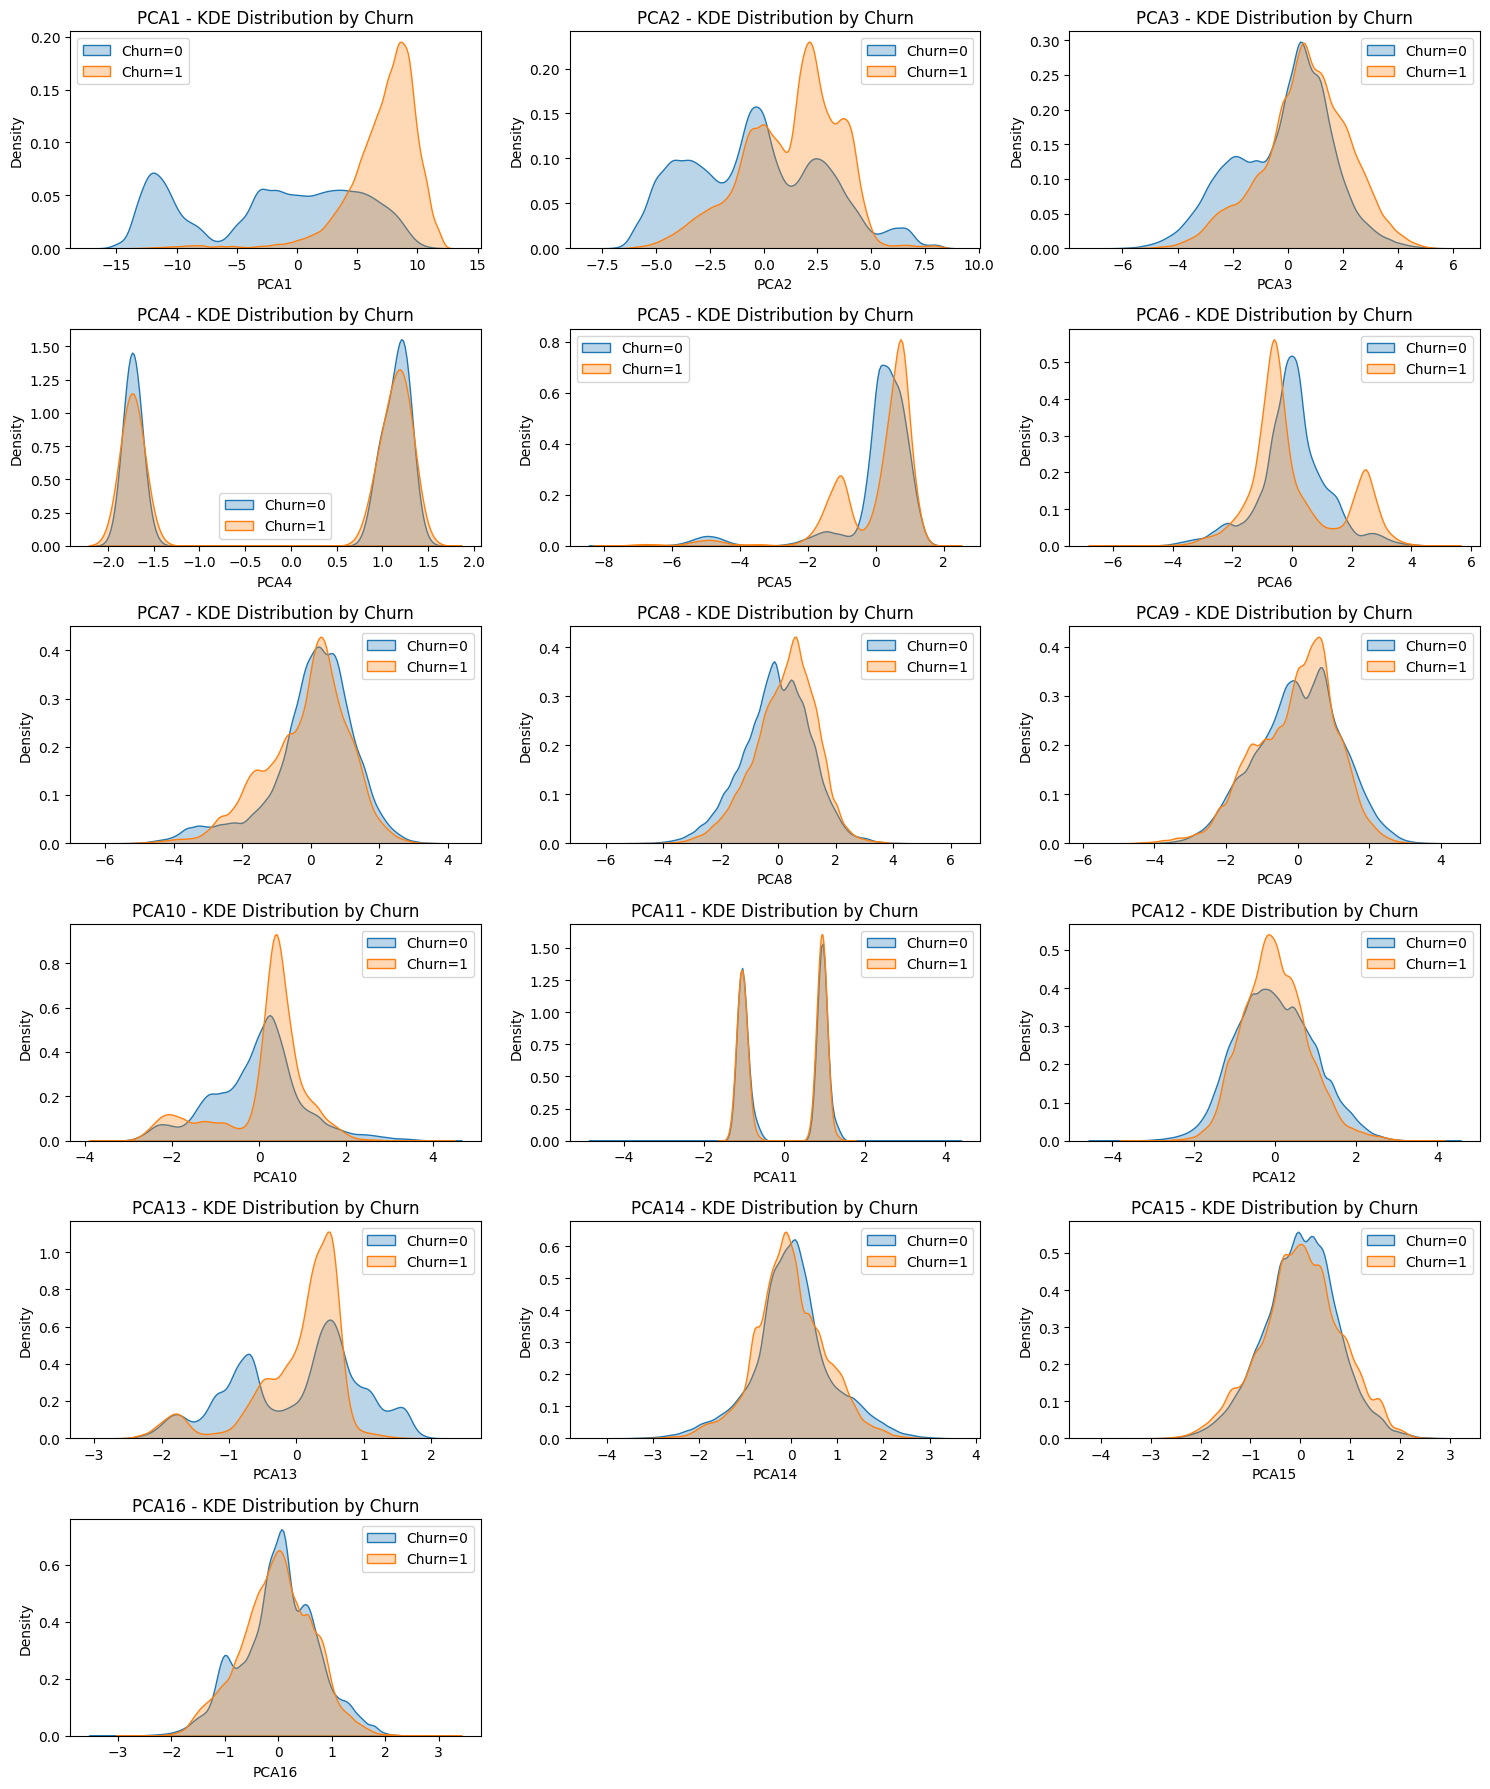

In [52]:
PCA_cols = [f"PCA{i}" for i in range(1, 17)]

def plot_kde_by_label(df, nums_cols, label_col, n_cols=3, figsize_per_plot=(5,3), alpha=0.3):
    n_rows = int(len(nums_cols) / n_cols) + (len(nums_cols) % n_cols != 0)
    plt.figure(figsize=(figsize_per_plot[0]*n_cols, figsize_per_plot[1]*n_rows))

    for i, col in enumerate(nums_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        for label in df[label_col].unique():
            subset = df[df[label_col] == label]
            sns.kdeplot(subset[col], label=f"{label_col}={label}", fill=True, alpha=alpha)
        
        plt.title(f"{col} - KDE Distribution by {label_col}")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
plot_kde_by_label(train, nums_cols=PCA_cols, label_col='Churn')

In [53]:
from sklearn.feature_selection import mutual_info_classif
pca_features=PCA_cols
train_pca_df = train[pca_features]
y = train["Churn"]

def evaluate_pca_contribution(pca_df, y):
    from sklearn.metrics import roc_auc_score
    
    results = []
    for col in pca_df.columns:
        mi = mutual_info_classif(pca_df[[col]], y)[0]
        auc = roc_auc_score(y, pca_df[col])
        if auc < 0.5: auc = 1 - auc 
        
        results.append({'Feature': col, 'MI Score': mi, 'Individual AUC': auc})
    
    return pd.DataFrame(results).sort_values(by='Individual AUC', ascending=False)

eval_summary = evaluate_pca_contribution(train_pca_df, y)
print(eval_summary)

   Feature  MI Score  Individual AUC
0     PCA1  0.213356        0.899420
1     PCA2  0.065343        0.666957
2     PCA3  0.041743        0.626871
9    PCA10  0.052878        0.595163
7     PCA8  0.026547        0.581503
5     PCA6  0.075058        0.550723
6     PCA7  0.028445        0.545748
3     PCA4  0.071427        0.517346
4     PCA5  0.062724        0.516539
13   PCA14  0.024795        0.516232
8     PCA9  0.022579        0.515902
15   PCA16  0.021963        0.515238
10   PCA11  0.026446        0.512383
12   PCA13  0.085856        0.509610
14   PCA15  0.022009        0.503719
11   PCA12  0.026287        0.501931


# KNN Analysis

In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

def find_best_k(train_df, feature_cols, target_col, k_range=range(10, 201, 20), n_splits=5):
    X = train_df[feature_cols].values
    y = train_df[target_col].values
    
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)
    
    k_scores = []
    
    print(f"[*] Starting K-selection process (CV={n_splits})...")
    
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X_std, y, cv=n_splits, scoring='roc_auc')
        mean_score = scores.mean()
        k_scores.append(mean_score)
        print(f"  > Testing K={k:3d} | Mean AUC: {mean_score:.4f}")
    
    best_idx = np.argmax(k_scores)
    best_k = list(k_range)[best_idx]
    best_score = k_scores[best_idx]
    
    print(f"\n[!] Optimization Complete.")
    print(f"[+] Best K: {best_k} with AUC: {best_score:.4f}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(k_range, k_scores, marker='o', linestyle='--', color='b')
    plt.axvline(x=best_k, color='r', linestyle=':', label=f'Best K={best_k}')
    plt.title('K-Value Optimization for KNN Feature')
    plt.xlabel('Value of K')
    plt.ylabel('Cross-Validated ROC AUC')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return best_k

kmeans_features = ['PCA1']
#best_k = find_best_k(train, kmeans_features, 'Churn', k_range=range(20, 301, 20))

In [55]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.model_selection import cross_val_score

def build_knn_feature(train_df, test_df, feature_cols, target_col, fixed_k=100, n_splits=5):
    X_train = train_df[feature_cols].values
    X_test = test_df[feature_cols].values
    y_train = train_df[target_col].values
    
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_test_std = scaler.transform(X_test)
    
    feature_name = f'KNN_Prob_K{fixed_k}'
    knn = KNeighborsClassifier(n_neighbors=fixed_k)
    
    print(f"[*] Generating OOF features for Train (K={fixed_k})...")
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    train_df[feature_name] = cross_val_predict(knn, X_train_std, y_train, cv=skf, method='predict_proba')[:, 1]
    
    print(f"[*] Generating features for Test...")
    knn.fit(X_train_std, y_train)
    test_df[feature_name] = knn.predict_proba(X_test_std)[:, 1]
    
    print(f"[+] Feature created: {feature_name}")
    return train_df, test_df

kmeans_features = ['PCA1']
train, test = build_knn_feature(train, test, feature_cols=kmeans_features, target_col='Churn')

[*] Generating OOF features for Train (K=100)...
[*] Generating features for Test...
[+] Feature created: KNN_Prob_K100


# K-Means Analysis

 best K = 3


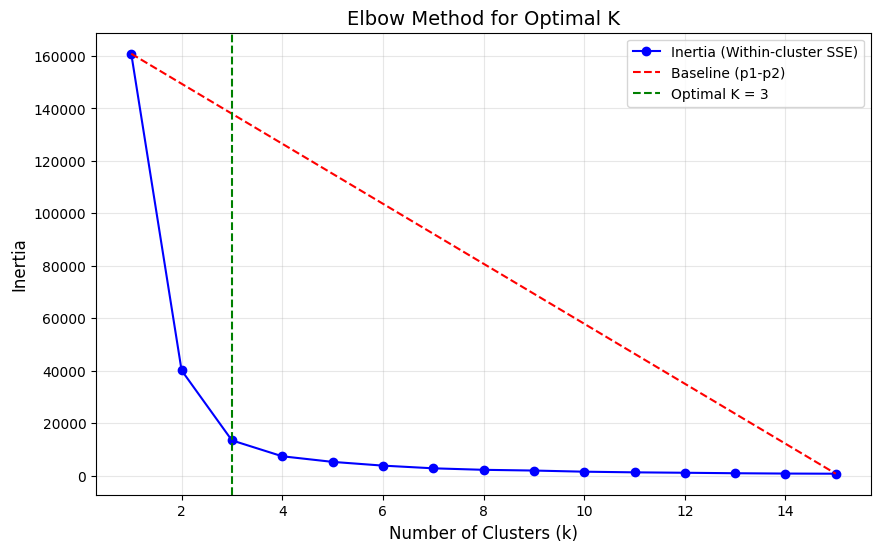

add 4 features to train data


In [56]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import MiniBatchKMeans
def auto_kmeans_features(train_df, test_df, feature_list, max_k=15):
    
    scaler = MinMaxScaler(feature_range=(-1, 1))
    
    train_scaled = scaler.fit_transform(train_df[feature_list])
    test_scaled = scaler.transform(test_df[feature_list])
    
    inertias = []
    k_range = range(1, max_k + 1)
    for k in k_range:
        km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10000, n_init=3)
        km.fit(train_scaled)
        inertias.append(km.inertia_)
    
    p1, p2 = np.array([k_range[0], inertias[0]]), np.array([k_range[-1], inertias[-1]])
    distances = [np.abs(np.cross(p2-p1, p1-np.array([k_range[i], inertias[i]]))) / np.linalg.norm(p2-p1) for i in range(len(k_range))]
    optimal_k = k_range[np.argmax(distances)]
    print(f" best K = {optimal_k}")

    
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertias, 'bo-', label='Inertia (Within-cluster SSE)')
    plt.plot([k_range[0], k_range[-1]], [inertias[0], inertias[-1]], 'r--', label='Baseline (p1-p2)')
    plt.axvline(x=optimal_k, color='green', linestyle='--', label=f'Optimal K = {optimal_k}')
    plt.title('Elbow Method for Optimal K', fontsize=14)
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('Inertia', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    final_kmeans = MiniBatchKMeans(n_clusters=optimal_k, random_state=42, batch_size=10000)
    
    train_df['knn_cluster'] = final_kmeans.fit_predict(train_scaled)
    test_df['knn_cluster'] = final_kmeans.predict(test_scaled)
    
    
    train_dists = final_kmeans.transform(train_scaled)
    test_dists = final_kmeans.transform(test_scaled)
    
    for i in range(optimal_k):
        train_df[f'knn_dist_center_{i}'] = train_dists[:, i]
        test_df[f'knn_dist_center_{i}'] = test_dists[:, i]
        
    print(f"add {optimal_k + 1} features to train data")
    return train_df, test_df, final_kmeans


knn_features = ['PCA1']
train, test, model = auto_kmeans_features(train, test, knn_features)

# Frequency Encode

In [57]:
fe_cols = train.select_dtypes(include='object').columns.tolist()
def frequency_encode(train_df, test_df, cat_cols, suffix="_freq", normalize=True):
    train_df = train_df.copy()
    test_df = test_df.copy()

    n = len(train_df)

    for col in cat_cols:
        new_col = col + suffix

        freq = train_df[col].value_counts()
        if normalize:
            freq = freq / n

        train_df[new_col] = train_df[col].map(freq)
        test_df[new_col] = test_df[col].map(freq).fillna(0)

    return train_df, test_df

train,test = frequency_encode(train_df=train,test_df=test,cat_cols=fe_cols)

# Target Encode

In [58]:
te_cols = train.select_dtypes(include='object').columns.tolist()
print("Have {} features to target encode".format(len(te_cols)))

def target_encode(train_df, test_df, cat_cols, target_col="Churn", n_splits=5, smooth=20, random_state=42):
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    global_mean = train_df[target_col].mean()

    # Target Encoding
    for feature in cat_cols:
        print(f"Encoding: {feature}")
        train_encoded = pd.Series(index=train_df.index, dtype=float)
        test_encoded = pd.Series(index=test_df.index, dtype=float)

        # train TE (OOF)
        for train_idx, val_idx in skf.split(train_df,train_df[target_col]):
            tr, val = train_df.iloc[train_idx], train_df.iloc[val_idx]
            stats = tr.groupby(feature)[target_col].agg(['mean', 'count'])
            smooth_mean = (stats['mean'] * stats['count'] + global_mean * smooth) / (stats['count'] + smooth)
            train_encoded.iloc[val_idx] = val[feature].map(smooth_mean.to_dict()).fillna(global_mean)

        # test TE
        stats = train_df.groupby(feature)[target_col].agg(['mean', 'count'])
        smooth_mean = (stats['mean'] * stats['count'] + global_mean * smooth) / (stats['count'] + smooth)
        test_encoded[:] = test_df[feature].map(smooth_mean.to_dict()).fillna(global_mean)

        # save mean 
        train_df[f"{feature}_te"] = train_encoded
        test_df[f"{feature}_te"] = test_encoded

    print("Finish TE mean")
    
    return train_df, test_df

train, test = target_encode(train, test, te_cols, target_col="Churn")

Have 72 features to target encode
Encoding: InternetService
Encoding: OnlineSecurity
Encoding: OnlineBackup
Encoding: DeviceProtection
Encoding: TechSupport
Encoding: StreamingTV
Encoding: StreamingMovies
Encoding: Contract
Encoding: PaperlessBilling
Encoding: PaymentMethod
Encoding: tenure_decile
Encoding: MonthlyCharges_decile
Encoding: TotalCharges_decile
Encoding: tenure_cate
Encoding: tenure_cate_Contract
Encoding: tenure_cate_PaymentMethod
Encoding: tenure_cate_MonthlyCharges_rank
Encoding: tenure_cate_InternetService
Encoding: tenure_cate_OnlineSecurity
Encoding: tenure_cate_TechSupport
Encoding: Contract_PaymentMethod
Encoding: Contract_MonthlyCharges_rank
Encoding: Contract_InternetService
Encoding: Contract_OnlineSecurity
Encoding: Contract_TechSupport
Encoding: PaymentMethod_MonthlyCharges_rank
Encoding: PaymentMethod_InternetService
Encoding: PaymentMethod_OnlineSecurity
Encoding: PaymentMethod_TechSupport
Encoding: MonthlyCharges_rank_InternetService
Encoding: MonthlyCharg

# Label Encode

In [60]:
from sklearn.preprocessing import LabelEncoder

le_cols = train.select_dtypes(include='object').columns.tolist()

def apply_label_encoding(train_df, test_df, categorical_cols):
    train_le = train_df.copy()
    test_le = test_df.copy()
    encoders = {}

    for col in categorical_cols:
        le = LabelEncoder()
        
        train_le[col] = le.fit_transform(train_le[col].astype(str))
        
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        
        test_le[col] = test_le[col].astype(str).map(mapping).fillna(-1).astype(int)
        
        encoders[col] = le
        
    print(f"Label Encoding for {len(categorical_cols)} columns has been completed")
    return train_le, test_le, encoders


train, test, le_dict = apply_label_encoding(train, test, le_cols)

Label Encoding for 72 columns has been completed


# One Hot Encode

In [ ]:
def one_hot_encode(train_df, test_df, cat_cols, drop_first=False):
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_ohe = pd.get_dummies(train_df[cat_cols], columns=cat_cols, drop_first=drop_first,dtype=int)
    
    test_ohe = pd.get_dummies(test_df[cat_cols], columns=cat_cols, drop_first=drop_first,dtype=int)

    test_ohe = test_ohe.reindex(columns=train_ohe.columns, fill_value=0).astype(int)

    train_df = pd.concat([train_df.drop(columns=cat_cols), train_ohe], axis=1)
    test_df = pd.concat([test_df.drop(columns=cat_cols), test_ohe], axis=1)

    return train_df, test_df

#train, test = one_hot_encode(train_df=train, test_df=test, cat_cols=cate_cols)

# Features Selection

In [62]:
object_cols = train.select_dtypes(include='object').columns.tolist()
train = train.drop(columns=object_cols,axis=1)
test = test.drop(columns=object_cols,axis=1)

In [63]:
Y = train["Churn"]
select_train = train.drop(columns="Churn",axis=1)

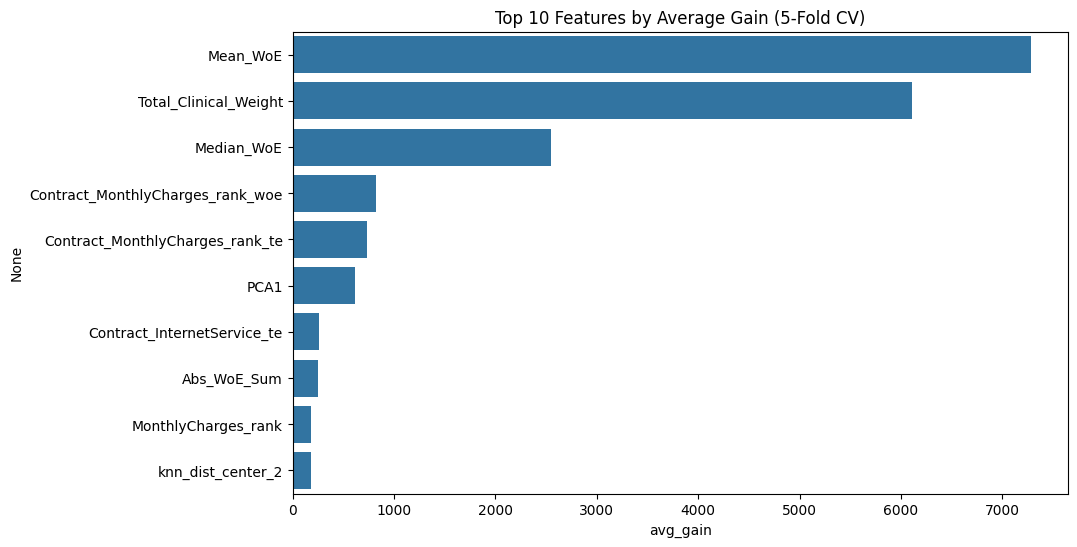

Total Data (594194, 384)
Features Select by gain is 363


In [65]:
import xgboost as xgb
from operator import itemgetter
from xgboost import plot_importance

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_importances = pd.DataFrame(index=select_train.columns)

xgb_params = {
        'n_jobs': -1,
        'objective':'binary:logistic',
        'tree_method': 'hist',       # GPU
        'device': 'cuda',
        'verbosity': 0,
        'random_state': 42,
        'max_depth':6,
        'learning_rate':0.01,
        'subsample':0.8,
        'colsample_bytree':0.8,
        'n_estimators':1000
    }

for i, (train_idx, val_idx) in enumerate(skf.split(select_train, Y)):
    X_tr, X_val = select_train.iloc[train_idx], select_train.iloc[val_idx]
    y_tr, y_val = Y.iloc[train_idx], Y.iloc[val_idx]
    
    model = xgb.XGBClassifier(**xgb_params)
    
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    scores = model.get_booster().get_score(importance_type='gain')
    cv_importances[f'fold_{i}'] = pd.Series(scores)

#cv_importances['avg_gain'] = cv_importances.mean(axis=1)
cv_importances = cv_importances.fillna(0)
cv_importances['avg_gain'] = cv_importances[[f'fold_{i}' for i in range(5)]].mean(axis=1)
importance_gains = model.get_booster().get_score(importance_type='gain')
ranked_features = cv_importances['avg_gain'].sort_values(ascending=False).index.tolist()

#plot_importance(model, importance_type='gain', max_num_features=10)
plt.figure(figsize=(10, 6))
top_10 = cv_importances.sort_values(by='avg_gain', ascending=False).head(10)
sns.barplot(x=top_10['avg_gain'], y=top_10.index)
plt.title('Top 10 Features by Average Gain (5-Fold CV)')
plt.show()


print("Total Data {}".format(select_train.shape))
print("Features Select by gain is {}".format(len(importance_gains)))

# Train Single Xgboost 

In [66]:
from xgboost import XGBClassifier

final_k = 363
final_select_features = ranked_features[:final_k]
quick_X = train[final_select_features]
quick_test = test[final_select_features]


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb1_scores = []
xgb1_oof = np.zeros(len(quick_X))
xgb1_pred = np.zeros(len(quick_test))   

for i, (train_ix, test_ix) in enumerate(skf.split(quick_X, Y)):
    
    X_train, X_valid = quick_X.iloc[train_ix], quick_X.iloc[test_ix]
    Y_train, Y_valid = Y.iloc[train_ix], Y.iloc[test_ix]

    xgb_md1 = XGBClassifier(
        tree_method='hist',
        grow_policy='lossguide',
        max_depth=0,
        objective='binary:logistic',
        eval_metric='auc',
        device='cuda',
        learning_rate=0.01,
        n_estimators=10000,
        colsample_bytree=0.8,
        max_leaves=256,
        min_child_weight=50, 
        subsample=0.8,
        reg_alpha = 0.1,
        reg_lambda = 1,
        gamma=0.1,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=200
    )

    xgb_md1.fit(
        X_train,
        Y_train,
        eval_set=[(X_valid, Y_valid)],
        verbose=200
    )

    # OOF prediction
    xgb_pred1 = xgb_md1.predict_proba(
        X_valid,
        iteration_range=(0, xgb_md1.best_iteration + 1)
    )[:, 1]

    xgb1_oof[test_ix] = xgb_pred1

    
    xgb1_pred += xgb_md1.predict_proba(
        quick_test,
        iteration_range=(0, xgb_md1.best_iteration + 1)
    )[:, 1] / skf.n_splits   

    xgb1_roc_auc_fold = roc_auc_score(Y_valid, xgb_pred1)
    xgb1_scores.append(xgb1_roc_auc_fold)

    print(f"Fold {i+1} ==> ROC AUC = {xgb1_roc_auc_fold:.5f}")

print(f"\nMean ROC AUC: {np.mean(xgb1_scores):.5f}")

[0]	validation_0-auc:0.90940
[200]	validation_0-auc:0.91411
[400]	validation_0-auc:0.91519
[600]	validation_0-auc:0.91585
[800]	validation_0-auc:0.91614
[1000]	validation_0-auc:0.91619
[1200]	validation_0-auc:0.91618
[1283]	validation_0-auc:0.91618
Fold 1 ==> ROC AUC = 0.91620
[0]	validation_0-auc:0.91055
[200]	validation_0-auc:0.91507
[400]	validation_0-auc:0.91618
[600]	validation_0-auc:0.91684
[800]	validation_0-auc:0.91710
[1000]	validation_0-auc:0.91720
[1200]	validation_0-auc:0.91720
[1259]	validation_0-auc:0.91718
Fold 2 ==> ROC AUC = 0.91723
[0]	validation_0-auc:0.91022
[200]	validation_0-auc:0.91443
[400]	validation_0-auc:0.91547
[600]	validation_0-auc:0.91612
[800]	validation_0-auc:0.91636
[1000]	validation_0-auc:0.91645
[1200]	validation_0-auc:0.91647
[1400]	validation_0-auc:0.91644
[1403]	validation_0-auc:0.91644
Fold 3 ==> ROC AUC = 0.91648
[0]	validation_0-auc:0.91048
[200]	validation_0-auc:0.91537
[400]	validation_0-auc:0.91660
[600]	validation_0-auc:0.91730
[800]	valida

# Tree-based Leaf Analysis

In [ ]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
            tree_method='hist',     
            objective='binary:logistic',
            device='cuda',
            booster='gbtree',
            learning_rate=0.01,
            n_estimators=1684,
            max_depth=6,                             
            colsample_bytree=0.65,
            reg_alpha = 0.1,
            reg_lambda = 1.0,
            gamma=0.1,
            eval_metric='logloss',
            subsample=0.8,
            random_state=42,
            n_jobs=-1)
xgb_model.fit(select_train,Y)

In [ ]:
def extract_xgboost_auc_rules(model, X, y, feature_names, top_n=10):
    
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=feature_names)
    
    
    booster = model.get_booster() if hasattr(model, 'get_booster') else model
    
    
    dmat = xgb.DMatrix(X, feature_names=feature_names)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else model.predict(dmat)
    
    global_pos_rate = y.mean()
    df_tree = booster.trees_to_dataframe()

    
    top_leaves = df_tree[df_tree['Feature'] == 'Leaf'].sort_values('Gain', ascending=False).head(top_n * 5)
    
    results = []
    seen_rules = set()

    for _, leaf in top_leaves.iterrows():
        tree_id, node_id = leaf['Tree'], leaf['ID']
        current_node, conditions = node_id, []
        
        while True:
            parent = df_tree[(df_tree['Tree'] == tree_id) & 
                             ((df_tree['Yes'] == current_node) | (df_tree['No'] == current_node))]
            if parent.empty: break
            
            p_node = parent.iloc[0]
        
            op = "<=" if p_node['Yes'] == current_node else ">"
            conditions.append(f"`{p_node['Feature']}` {op} {p_node['Split']:.4f}")
            current_node = p_node['ID']
        
        rule_str = " & ".join(conditions[::-1])
        if rule_str in seen_rules: continue
        seen_rules.add(rule_str)

        try:
            mask = X.eval(rule_str)
            
            if mask.sum() < 20 or y[mask].nunique() < 2: 
                continue 
            
            local_auc = roc_auc_score(y[mask], y_prob[mask])
            precision = y[mask].mean()
            lift = precision / global_pos_rate
            
            results.append({
                "Rule": rule_str,
                "Local_AUC": round(local_auc, 4), 
                "Precision": round(precision, 4),  
                "Lift": round(lift, 2),            
                "Coverage": f"{mask.mean():.2%}",
                "Sample_Size": mask.sum()
            })
        except Exception as e:
            continue

    return pd.DataFrame(results).sort_values("Lift", ascending=False).head(top_n)

nums_cols = select_train.columns.tolist()
results = extract_xgboost_auc_rules(xgb_model, select_train, Y, nums_cols)

In [ ]:
pd.set_option('display.max_colwidth', None)
results

# Hyperparameter Search

In [ ]:
final_k=289

final_select_features = ranked_features[:final_k]

X = select_train[final_select_features]
test = test[final_select_features]

print("We choose {} features for trees".format(len(final_select_features)))
print("The train data shape is {}".format(X.shape))
print("The test data shape is {}".format(test.shape))
print("The Target shape is {}".format(Y.shape))

In [ ]:
import optuna
# trees_number     -> how many tree
# tree_complexity  -> max_depth
# regularization -> overfitting control
# row_sampling -> data random
# col_sampling -> features random
# learning_rate -> step

def suggest_shared_params(trial):
    return {
        # scale
        "trees_number":trial.suggest_int("trees_number",100,3000),
        "learning_rate":trial.suggest_float("learning_rate",0.005,0.2,log=True),
        # structure
        "tree_complexity":trial.suggest_int("tree_complexity",1,12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 200), 
        # re
        "regularization":trial.suggest_float("regularization",1e-3,10.0,log=True),
        # random
        "row_sampling":trial.suggest_float("row_sampling",0.5,1.0),
        "col_sampling":trial.suggest_float("col_sampling",0.5,1.0)
    
    }

# CV Evaluation Function

In [ ]:
from sklearn.metrics import roc_auc_score

def cv_roc_auc(model_builder, X, Y, kf):
    
    oof_probs = np.zeros(len(X))

    for tr_idx, val_idx in kf.split(X, Y):
        model = model_builder()
        model.fit(X.iloc[tr_idx], Y.iloc[tr_idx])
        
        if hasattr(model, "predict_proba"):
            oof_probs[val_idx] = model.predict_proba(X.iloc[val_idx])[:, 1]
        else:
            oof_probs[val_idx] = model.predict(X.iloc[val_idx])

    auc_score = roc_auc_score(Y, oof_probs)
    return auc_score

# Define Search Model

In [ ]:
from xgboost import XGBClassifier

def build_xgb_clf(shared):
    max_leaves_val = 2 ** int(shared["tree_complexity"])
    
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        grow_policy="lossguide",
        device="cuda",
        random_state=42,
        n_jobs=-1,

        n_estimators=int(shared["trees_number"]),
        learning_rate=shared["learning_rate"],

        max_leaves=max_leaves_val,
        min_child_weight=shared["min_child_samples"], 

        reg_lambda=shared["regularization"],
        
        subsample=shared["row_sampling"],
        colsample_bytree=shared["col_sampling"]
    )

# Optuna Objective

In [ ]:
def objective(trial):
    shared = suggest_shared_params(trial)
    
    from sklearn.model_selection import StratifiedKFold
    
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_score = cv_roc_auc(lambda: build_xgb_clf(shared), X, Y, kf)

    return auc_score

# Starting Optuna search

In [ ]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(
        multivariate=True,
        group=True,
        seed=42
    )
)

study.optimize(objective, n_trials=30)

In [ ]:
optuna.visualization.plot_optimization_history(study).show()
#optuna.visualization.plot_parallel_coordinate(study, params=['learning_rate','trees_number', 'tree_complexity', 'regularization','row_sampling','col_sampling']).show()

# Train All Model

# Define Base Params

In [ ]:
best_params = {'trees_number': 2321,
               'learning_rate': 0.019077825791399432,
               'tree_complexity': 11,
               'min_child_samples': 91,
               'regularization': 0.0013110894251274702,
               'row_sampling': 0.939105051971213, 
               'col_sampling': 0.781865707800904}

# Main Train 

In [ ]:
import time
import warnings
warnings.filterwarnings("ignore")
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.special import expit
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

class EnsembleModelTrainer:
    def __init__(self,params,n_splits=5,random_state=42):
        self.shared = params
        self.n_splits = n_splits
        self.random_state = random_state
        self.skf = StratifiedKFold(n_splits=self.n_splits,shuffle=True,random_state=self.random_state)

        self.scores = {
            "xgb_base":[],"xgb_grow_policy":[],"xgb_aggressive":[],
            "lgbm_base":[],"lgbm_subspace":[],"lgbm_conservative":[],
            "cat_base":[],"cat_lossguide":[],"cat_aggressive":[],
            "ens":[],"hill":[]
        }

        self.test_preds = {k:[] for k in self.scores}
    
        self.hill_weights = []
        
    #---predict---
    def _predict_proba_safe(self,model,X):
        
        if hasattr(model,"predict_proba"):
            return model.predict_proba(X)[:,1]
            
        elif hasattr(model,"decision_function"):
            return expit(model.decision_function(X))
            
        else:
            raise ValueError("Model has no probability output")
            
    #---model---
    def _build_xgb_models(self):
        s = self.shared
        # (Base Params)
        base_config = {
            "tree_method": "hist",
            "objective": "binary:logistic",
            "device": "cuda",
            "n_estimators": s["trees_number"],
            "learning_rate": s["learning_rate"],
            "max_depth": s["tree_complexity"],
            "subsample": s["row_sampling"],
            "colsample_bytree": s["col_sampling"],
            "reg_lambda": s["regularization"],
            "eval_metric": "auc",
            "n_jobs": -1}

        return {
            # 1. (Base)
            "xgb_base": XGBClassifier(**base_config, random_state=42),

            # 2. (Loss-guide)
            "xgb_grow_policy": XGBClassifier(
                **base_config,
                grow_policy="lossguide",
                max_leaves=2 ** (s["tree_complexity"]), 
                random_state=142
            ),

            # 3. (Feature Subspace)
            #"xgb_subspace": XGBClassifier(
    
            #    colsample_bytree=max(0.5, s["col_sampling"] - 0.2), 
            #    n_estimators=s["trees_number"] + 50,              
            #    random_state=242
            #),

            # 4. (Conservative/Regularized)
            #"xgb_conservative": XGBClassifier(

             #   reg_lambda=s["regularization"] * 3.0,             
             #   learning_rate=s["learning_rate"] * 1.2,           
             #   max_depth=s["tree_complexity"] - 1,               
             #   random_state=342
            #),

            # 5. (Aggressive/Deep)
            "xgb_aggressive": XGBClassifier(
            
                learning_rate=s["learning_rate"] * 0.5,           
                n_estimators=int(s["trees_number"] * 1.5),        
                max_depth=s["tree_complexity"] + 1,               
                subsample=min(1.0, s["row_sampling"] + 0.1),     
                random_state=442
            )
        }
    def _build_lgbm_models(self):
        s = self.shared
        # (Base Params)
        base_config = {
            "objective": "binary",
            "metric": "auc",
            "boosting_type": "gbdt",
            "device": "gpu",               
            "n_estimators": s["trees_number"],
            "learning_rate": s["learning_rate"],
            "max_depth": s["tree_complexity"],
            "num_leaves": int(0.8 * (2 ** s["tree_complexity"])), 
            "subsample": s["row_sampling"],
            "colsample_bytree": s["col_sampling"],
            "reg_lambda": s["regularization"],
            "n_jobs": -1,
            "importance_type": "gain"}

        return {
        # 1. (Base)
        "lgbm_base": LGBMClassifier(**base_config, random_state=42),

        #"lgbm_deep": LGBMClassifier(
            
        #    num_leaves=2 ** s["tree_complexity"], 
        #    learning_rate=s["learning_rate"] * 0.8,
        #    random_state=142
        #),

        # 3. (Feature Diversity)
        "lgbm_subspace": LGBMClassifier(
            
            colsample_bytree=max(0.4, s["col_sampling"] - 0.2),
            subsample=max(0.5, s["row_sampling"] - 0.1),
            n_estimators=int(s["trees_number"] * 1.2),
            random_state=242
        ),

        # 4. (Conservative)
        "lgbm_conservative": LGBMClassifier(
            
            reg_alpha=s["regularization"] * 0.5, 
            reg_lambda=s["regularization"] * 5.0, 
            min_split_gain=0.1,                
            random_state=342
        ),

        # 5. (Data Robustness)
        "lgbm_robust": LGBMClassifier(
            
            subsample=0.65,
            subsample_freq=5,                   
            learning_rate=s["learning_rate"] * 1.1,
            random_state=442
        )
    }
    def _build_catboost_models(self):
        s = self.shared
        # (Base Params)
        base_config = {
            "task_type": "GPU" if s.get("device") == "cuda" else "CPU",
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "iterations": s["trees_number"],
            "learning_rate": s["learning_rate"],
            "depth": s["tree_complexity"],
            "subsample": s["row_sampling"],
            "colsample_bylevel": s["col_sampling"], 
            "l2_leaf_reg": s["regularization"],
            "bootstrap_type": "Bernoulli", 
            "random_seed": 42,
            "verbose": False,
            "thread_count": -1}

        return {
        # (Base) 
        "cat_base": CatBoostClassifier(**base_config),

        "cat_lossguide": CatBoostClassifier(
            grow_policy="Lossguide",
            max_leaves=2 ** (s["tree_complexity"]),
            random_seed=142
        ),

        # 3. (Feature Subspace) 
        "cat_subspace": CatBoostClassifier(
            colsample_bylevel=max(0.5, s["col_sampling"] - 0.2),
            iterations=s["trees_number"] + 50,
            random_seed=242
        ),

        # 4. (Conservative/Regularized) 
        "cat_conservative": CatBoostClassifier(
            l2_leaf_reg=s["regularization"] * 3.0,
            learning_rate=s["learning_rate"] * 1.2,
            depth=max(1, s["tree_complexity"] - 1),
            random_seed=342
        ),

        # 5. (Aggressive/Deep) 
        "cat_aggressive": CatBoostClassifier(
            learning_rate=s["learning_rate"] * 0.5,
            iterations=int(s["trees_number"] * 1.5),
            depth=min(16, s["tree_complexity"] + 1),
            subsample=min(1.0, s["row_sampling"] + 0.1),
            random_seed=442
        )
    }
    
    #---get_model---
    def _get_models(self):
        
        models = {}
        models.update(self._build_xgb_models())
        models.update(self._build_lgbm_models())
        models.update(self._build_catboost_models())
        return models
        
    #---training---
    def train_and_evaluate(self, X_tree, X_test_tree, Y, hill_climbing_func):
        print(f'{"-"*30} Training Started {"-"*30}')

        for fold, (tr_idx, va_idx) in enumerate(self.skf.split(X_tree, Y), 1):

            print(f'\n{"-"*20} Fold {fold} {"-"*20}')

            X_tr = X_tree.iloc[tr_idx]
            X_va = X_tree.iloc[va_idx]

            y_tr = Y.iloc[tr_idx]
            y_va = Y.iloc[va_idx]

            models = self._get_models()

            fold_val_preds = {}
            fold_test_preds = {}

            # ----- Base models -----
            for name, model in models.items():
                
                start = time.time()
                model.fit(X_tr, y_tr)

                val_pred = self._predict_proba_safe(model, X_va)
                test_pred = self._predict_proba_safe(model, X_test_tree)

                score = roc_auc_score(y_va, val_pred)

                self.scores[name].append(score)
                self.test_preds[name].append(test_pred)

                fold_val_preds[name] = val_pred
                fold_test_preds[name] = test_pred

                print(f"{name.upper():20s} AUC {score:.5f} | {time.time()-start:.1f}s")

            # ----- Simple Average -----
            ens_val = np.mean(list(fold_val_preds.values()), axis=0)
            ens_score = roc_auc_score(y_va, ens_val)
            self.scores["ens"].append(ens_score)

            ens_test = np.mean(list(fold_test_preds.values()), axis=0)
            self.test_preds["ens"].append(ens_test)

            print(f"ENS  ROC AUC: {ens_score:.5f}")

            # ----- Hill Climbing -----
            df_val = pd.DataFrame(fold_val_preds)
            df_test = pd.DataFrame(fold_test_preds)

            res = hill_climbing_func(df_val, y_va, df_test)
            hill_val = res["oof_pred"]
            hill_test = res["test_pred"]
            hill_weights = res["weights"]
            self.hill_weights.append(hill_weights)
            hill_score = roc_auc_score(y_va, hill_val)

            self.scores["hill"].append(hill_score)
            self.test_preds["hill"].append(hill_test)

            print(f"HILL  ROC AUC: {hill_score:.5f}")

        self._print_summary()

    # ---Summary ---
    def _print_summary(self, plot=True):
        print(f'\n{"-"*30} Final CV Results {"-"*30}')

        model_names = []
        mean_scores = []
        std_scores = []

        for k, v in self.scores.items():
            if v:
                mean_score = np.mean(v)
                std_score = np.std(v)

                model_names.append(k.upper())
                mean_scores.append(mean_score)
                std_scores.append(std_score)

                print(f"{k.upper():5s} ROC AUC: {mean_score:.5f} (+/- {std_score:.5f})")

        if plot and model_names:
            plt.figure(figsize=(12, 4))
            plt.plot(model_names, mean_scores, marker="o")
            plt.xlabel("Model")
            plt.ylabel("Mean ROC AUC")
            plt.title("CV Performance by Model")
            plt.xticks(rotation=45, ha="right")
            plt.grid(True)
            plt.show()

    # ---------- Final Prediction ----------
    def get_final_predictions(self, method="hill"):
        return np.mean(self.test_preds[method], axis=0)

    #---------- Get hill climbing weights ----------
    def get_final_hill_weights(self):
        df = pd.DataFrame(self.hill_weights)
        df.loc['mean'] = df.mean()
        return df

# Define Hill Climing

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

def hill_climbing_auc(x_oof, y, x_test):
    scores = {}
    for col in x_oof.columns:
        scores[col] = roc_auc_score(y, x_oof[col])

    scores = {k: v for k, v in sorted(scores.items(), key=lambda item: item[1], reverse=True)}

    x_oof = x_oof[list(scores.keys())]
    x_test = x_test[list(scores.keys())]

    STOP = False
    current_best_ensemble = x_oof.iloc[:, 0].copy()
    current_best_test_preds = x_test.iloc[:, 0].copy()
    
    final_weights = {list(scores.keys())[0]: 1.0}
    for col in list(scores.keys())[1:]:
        final_weights[col] = 0.0

    MODELS = x_oof.iloc[:, 1:].copy()
    weight_range = np.arange(0, 0.51, 0.01) 
    history = [roc_auc_score(y, current_best_ensemble)]
    
    while not STOP:
        potential_new_best_cv_score = roc_auc_score(y, current_best_ensemble)
        k_best, wgt_best = None, None
        
        for k in MODELS.columns:
            for wgt in weight_range:
                potential_ensemble = (1 - wgt) * current_best_ensemble + wgt * MODELS[k]
                cv_score = roc_auc_score(y, potential_ensemble)
                
                if cv_score > potential_new_best_cv_score: 
                    potential_new_best_cv_score = cv_score
                    k_best, wgt_best = k, wgt

        if k_best is not None:
            for model_name in final_weights:
                final_weights[model_name] *= (1 - wgt_best)
            final_weights[k_best] += wgt_best
            
            current_best_ensemble = (1 - wgt_best) * current_best_ensemble + wgt_best * MODELS[k_best]
            current_best_test_preds = (1 - wgt_best) * current_best_test_preds + wgt_best * x_test[k_best]
            
            MODELS.drop(k_best, axis=1, inplace=True)
            if MODELS.shape[1] == 0:
                STOP = True
            history.append(potential_new_best_cv_score)
        else:
            STOP = True

    return {
        "oof_pred": current_best_ensemble,
        "test_pred": current_best_test_preds,
        "weights": final_weights,
        "final_auc": history[-1]
    }

# Training

In [ ]:
#trainer = EnsembleModelTrainer(
   # params=best_params,
    #n_splits=5
#)

#trainer.train_and_evaluate(
  #  X_tree = X,
  #  X_test_tree=test,
  #  Y=Y,
  #  hill_climbing_func=hill_climbing_auc
#)

#hill_pred = trainer.get_final_predictions("hill")
#ens_pred = trainer.get_final_predictions("ens")

# Features Importance

In [ ]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
            tree_method='hist',     
            objective='binary:logistic',
            device='cuda',
            booster='gbtree',
            learning_rate=0.01,
            n_estimators=2321,
            max_depth=11,                             
            colsample_bytree=0.78,
            reg_alpha = 0.5,
            reg_lambda = 0.0013,
            gamma=0.5,
            eval_metric='logloss',
            subsample=0.93,
            random_state=42,
            n_jobs=-1)
xgb_model.fit(X,Y)

In [ ]:
from operator import itemgetter
from xgboost import plot_importance

importance_dict = xgb_model.get_booster().get_score(importance_type='gain')

importance_list = sorted(importance_dict.items(), key=itemgetter(1), reverse=True)

plot_importance(xgb_model, importance_type='gain', max_num_features=10)
plt.show()

# Submission

In [67]:
submission["Churn"] = xgb1_pred
submission.head()

,id,Churn
0,594194,0.067431
1,594195,0.001119
2,594196,0.159918
3,594197,0.004163
4,594198,0.618893


In [68]:
submission.to_csv("030.csv",index=False)

# CV and LB 

In [ ]:
def plot_cv_lb_with_annotated_gap(cv_list, lb_list):
    if len(cv_list) != len(lb_list):
        print(f"！CV: {len(cv_list)}, LB: {len(lb_list)}")
        return

    runs = range(1, len(cv_list) + 1)
    gaps = np.array(cv_list) - np.array(lb_list)
    df = pd.DataFrame({'Run_ID': runs, 'CV': cv_list, 'LB': lb_list, 'Gap': gaps})

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), sharex=True, 
                                   gridspec_kw={'height_ratios': [2, 1]})

    
    line1, = ax1.plot(df['Run_ID'], df['CV'], marker='o', label='Local CV', color='#1f77b4', lw=2)
    line2, = ax1.plot(df['Run_ID'], df['LB'], marker='s', label='Public LB', color='#ff7f0e', lw=2)
    
    
    for i, row in df.iterrows():
        ax1.annotate(f"{row['CV']:.5f}", (row['Run_ID'], row['CV']), textcoords="offset points", 
                     xytext=(0, 8), ha='center', fontsize=9, color='#1f77b4', fontweight='bold')
        ax1.annotate(f"{row['LB']:.5f}", (row['Run_ID'], row['LB']), textcoords="offset points", 
                     xytext=(0, -15), ha='center', fontsize=9, color='#d95f02', fontweight='bold')

    ax1.set_title(f"CV vs LB Trend (Corr: {df['CV'].corr(df['LB']):.4f})", fontsize=14, pad=10)
    ax1.set_ylabel("Metric Score")
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle=':', alpha=0.5)

    
    norm_gaps = (gaps - gaps.min()) / (gaps.max() - gaps.min() + 1e-9)
    colors = [plt.cm.RdYlGn(1 - g) for g in norm_gaps] 
    
    bars = ax2.bar(df['Run_ID'], df['Gap'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.5f}', 
                 ha='center', va='bottom' if height > 0 else 'top', fontsize=9, fontweight='bold')

    ax2.set_title("Gap Analysis (CV - LB)", fontsize=12)
    ax2.set_ylabel("Delta")
    ax2.set_xlabel("Experiment ID")
    ax2.axhline(0, color='black', lw=1)
    ax2.grid(axis='y', linestyle='--', alpha=0.4)

    plt.xticks(runs)
    plt.tight_layout()
    plt.show()

cv_scores = [0.91585,0.91566,0.91473,0.91529,0.91544,
             0.91531,0.91750,0.91767,0.91769,0.91793,
             0.91559,0.91561,0.91691,0.91561,0.91519,
            0.91548,0.91647,0.91409,0.91591,0.91589]

lb_scores = [0.91319,0.91174,0.91185,0.91168,0.91274,
             0.91154,0.91505,0.91545,0.91531,0.91549,
             0.91319,0.91327,0.91227,0.91286,0.91278,
            0.91217,0.91253,0.91144,0.91272,0.91269]

plot_cv_lb_with_annotated_gap(cv_scores, lb_scores)


# Have FUN!